# CH3CN T3NS 12dim 125N mu0 real

This notebook uses `SVD_MAX_BOND_DIM = 12` and `CHEB_TTNS_BASIS_SIZE = 125`. During rescaling, `E_min` and `psi_min` are loaded from `Results_final/ch3cn/threetree/max_bond_dim_12`, `E_max` is estimated by the local DMRG helper, and CBC Chebyshev data are loaded from `/Users/link/Desktop/A_Python_code/Chebyshev_upload/Chebyshev/CBC_result` while the other contraction methods keep their original settings.


In [28]:
import importlib
import copy
import time
import traceback
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from Experiment.potentials import get_potential_energy_CH3CN, get_potential_energy_CH3CN_harmonic
from Experiment.utils import get_orbitals_indices_first, get_energy_clusters, get_ttno
from Experiment.utils_ch3cn import random_mps_harmonic_oscillator_0, random_threetree_harmonic_oscillator_0, random_leafonly_harmonic_oscillator_0
from pytreenet.ttns import TreeTensorNetworkState
from pytreenet.ttno import TreeTensorNetworkOperator
from pytreenet.ttns.ttns_ttno.application import ApplicationMethod
from pytreenet.operators.models.two_site_model import XYModel
from pytreenet.operators.common_operators import *
from pytreenet.util import SVDParameters
from Dipole_moment import get_mu_ttno_linear
import utils_CH3CN as ch3cn_utils
from CheTTNS import *
ch3cn_utils = importlib.reload(ch3cn_utils)
CH3CN_IR_FREQ_CM_12 = ch3cn_utils.CH3CN_IR_FREQ_CM_12
CH3CN_IR_TRANSITION_DIPOLE_12 = ch3cn_utils.CH3CN_IR_TRANSITION_DIPOLE_12
CH3CN_ORCA_FUNDAMENTAL_FREQ_CM_12 = ch3cn_utils.CH3CN_ORCA_FUNDAMENTAL_FREQ_CM_12
get_ch3cn_ir_dipole_derivative = ch3cn_utils.get_ch3cn_ir_dipole_derivative
get_ch3cn_orca_permanent_dipole = ch3cn_utils.get_ch3cn_orca_permanent_dipole
get_ch3cn_orca_potential_energy = ch3cn_utils.get_ch3cn_orca_potential_energy


### CH3CN Hamiltonian


In [29]:
N = [9,7,9,9,9,9,7,7,9,9,27,27]
node_order = [0,1,2,3,4,5,6,7,8,9,10,11]

# Keep the ORCA TTNO manageable. Set this to 0.0 for the full ORCA VPT2
# force field; increase to 5.0 if TTNO construction becomes too heavy.
ORCA_FORCE_CONSTANT_CUTOFF_CM = 1.0

omega_experiment, _, _ = get_potential_energy_CH3CN_harmonic()
omega, k3_orca, k4_orca = get_ch3cn_orca_potential_energy(
    force_constant_cutoff_cm=ORCA_FORCE_CONSTANT_CUTOFF_CM,
)


def get_potential_energy_CH3CN_orca(alpha=1000):
    return get_ch3cn_orca_potential_energy(
        alpha=alpha,
        force_constant_cutoff_cm=ORCA_FORCE_CONSTANT_CUTOFF_CM,
    )


TTNS_NUM_ORB = 2
_, orb_state, orb_Es = get_orbitals_indices_first(omega_experiment, num_orb=TTNS_NUM_ORB)

state0 = random_threetree_harmonic_oscillator_0(N, omega_experiment, orb_state[:TTNS_NUM_ORB], node_order)

state0.canonical_form(state0.root_id)

ttno, _ = get_ttno(N, state0, get_potential_energy_CH3CN, True)

site_ids = list(state0.nodes.keys())
print("Number of sites:", len(site_ids))
print("Site ids:", site_ids)
print("Experiment harmonic omega cm^-1:", np.asarray(omega_experiment) * 1000.0)
print("ORCA harmonic omega cm^-1:", omega * 1000.0)
print("ORCA VPT2 fundamental cm^-1:", CH3CN_ORCA_FUNDAMENTAL_FREQ_CM_12)
print("ORCA - Experiment harmonic cm^-1:", omega * 1000.0 - np.asarray(omega_experiment) * 1000.0)
print("ORCA k3 nonzero:", int(np.count_nonzero(k3_orca)))
print("ORCA k4 nonzero:", int(np.count_nonzero(k4_orca)))
print("TTNS num_orb:", TTNS_NUM_ORB)
print("orb_Es:", orb_Es[:TTNS_NUM_ORB])
print("TTNO bond dims:", ttno.bond_dims())


/Users/link/Desktop/A_Python_code/Chebyshev_upload/Chebyshev/pytreenet/random/random_node.py:22: ComplexWarning: Casting complex values to real discards the imaginary part
  rand_tensor = crandn(shape, seed=seed).astype(dtype)


Number of sites: 13
Site ids: ['site12', 'site3', 'site2', 'site1', 'site0', 'site4', 'site5', 'site6', 'site7', 'site8', 'site9', 'site10', 'site11']
Experiment harmonic omega cm^-1: [3065. 2297. 1413.  920. 3149. 3149. 1487. 1487. 1061. 1061.  361.  361.]
ORCA harmonic omega cm^-1: [3048.42 2364.22 1413.32  929.02 3116.15 3116.39 1473.16 1473.19 1062.64
 1062.8   381.75  381.8 ]
ORCA VPT2 fundamental cm^-1: [2938.213 2338.018 1378.792  922.32  2972.062 2971.824 1444.841 1444.94
 1041.41  1041.275  383.882  383.631]
ORCA - Experiment harmonic cm^-1: [-16.58  67.22   0.32   9.02 -32.85 -32.61 -13.84 -13.81   1.64   1.8
  20.75  20.8 ]
ORCA k3 nonzero: 215
ORCA k4 nonzero: 338
TTNS num_orb: 2
orb_Es: [ 9.9055 10.2665]
TTNO bond dims: {('site12', 'site3'): 14, ('site3', 'site2'): 11, ('site2', 'site1'): 9, ('site1', 'site0'): 5, ('site12', 'site4'): 18, ('site4', 'site5'): 16, ('site5', 'site6'): 10, ('site6', 'site7'): 5, ('site12', 'site8'): 18, ('site8', 'site9'): 13, ('site9', 'site1

### Construct dipole moment


In [30]:
# ORCA harmonic transition dipoles in site order:
# [nu1, nu2, nu3, nu4, nu5a, nu5b, nu6a, nu6b, nu7a, nu7b, nu8a, nu8b]
# Use Tx/Ty/Tz separately. The total IR response is the sum of the three
# component spectra.
DIPOLE_COMPONENTS = ("x", "y", "z")
DIPOLE_INCLUDE_MU0 = False
CENTER_DIPOLE_WITH_PSI_MIN = True
dipole_mu0_by_component = dict(
    zip(DIPOLE_COMPONENTS, get_ch3cn_orca_permanent_dipole())
)
dipole_base_mu0_by_component = {
    component: dipole_mu0_by_component[component] if DIPOLE_INCLUDE_MU0 else 0.0
    for component in DIPOLE_COMPONENTS
}
dipole_derivative_by_component = {
    component: get_ch3cn_ir_dipole_derivative(normalize=False, component=component)
    for component in DIPOLE_COMPONENTS
}
transition_dipole_12 = np.column_stack(
    [dipole_derivative_by_component[component] for component in DIPOLE_COMPONENTS]
)

print("ORCA transition dipole components [Tx, Ty, Tz]:")
print(transition_dipole_12)
print("ORCA permanent dipole mu0 [x, y, z]:")
print([dipole_mu0_by_component[component] for component in DIPOLE_COMPONENTS])
print("DIPOLE_INCLUDE_MU0:", DIPOLE_INCLUDE_MU0)
print("CENTER_DIPOLE_WITH_PSI_MIN:", CENTER_DIPOLE_WITH_PSI_MIN)

mu_ttno_with_mu0_by_component = {
    component: get_mu_ttno_linear(
        N,
        state0,
        dipole_derivative_by_component[component],
        mu0=dipole_mu0_by_component[component],
    )
    for component in DIPOLE_COMPONENTS
}
mu_ttno_raw_by_component = {
    component: get_mu_ttno_linear(
        N,
        state0,
        dipole_derivative_by_component[component],
        mu0=0.0,
    )
    for component in DIPOLE_COMPONENTS
}

mu_ttno_by_component = (
    mu_ttno_with_mu0_by_component
    if DIPOLE_INCLUDE_MU0
    else mu_ttno_raw_by_component
)
mu_x_ttno = mu_ttno_by_component["x"]
mu_y_ttno = mu_ttno_by_component["y"]
mu_z_ttno = mu_ttno_by_component["z"]

for component in DIPOLE_COMPONENTS:
    print(f"mu_{component} with mu0 TTNO bond dims:", mu_ttno_with_mu0_by_component[component].bond_dims())
    print(f"mu_{component} no mu0 TTNO bond dims:", mu_ttno_raw_by_component[component].bond_dims())


ORCA transition dipole components [Tx, Ty, Tz]:
[[-7.8150e-03 -3.2000e-05 -1.0000e-06]
 [-1.6558e-02  2.0000e-06 -1.0000e-06]
 [-8.6240e-03 -3.2000e-05 -1.0000e-06]
 [-9.1340e-03  0.0000e+00  0.0000e+00]
 [ 2.5000e-05 -4.1430e-03 -3.2300e-04]
 [-1.0000e-06 -3.2000e-04  4.1780e-03]
 [ 2.0000e-06  1.3390e-03 -2.0902e-02]
 [ 9.0000e-06  2.0896e-02  1.3390e-03]
 [-2.0000e-06 -1.7300e-04 -1.0266e-02]
 [ 4.4000e-05 -1.0321e-02  1.7000e-04]
 [ 0.0000e+00 -3.1300e-04  1.0057e-02]
 [ 5.5000e-05  1.0026e-02  3.1400e-04]]
ORCA permanent dipole mu0 [x, y, z]:
[np.float64(0.161359895), np.float64(-0.092676601), np.float64(-1.574578465)]
DIPOLE_INCLUDE_MU0: False
CENTER_DIPOLE_WITH_PSI_MIN: True
mu_x with mu0 TTNO bond dims: {('site12', 'site3'): 2, ('site3', 'site2'): 2, ('site2', 'site1'): 2, ('site1', 'site0'): 2, ('site12', 'site4'): 2, ('site4', 'site5'): 2, ('site5', 'site6'): 2, ('site6', 'site7'): 2, ('site12', 'site8'): 2, ('site8', 'site9'): 2, ('site9', 'site10'): 2, ('site10', 'site11'):

### Rescale Hamiltonian


In [ ]:
from pathlib import Path

RESCALE_MAX_BOND_DIM = 12
RESCALE_NUM_SWEEPS = 1
RESCALE_MAX_ITER = 40
RESCALE_DMRG_SITE = "two-site"
RESCALE_W_PRIME = 0.9875
RESCALE_SAFETY_FACTOR = 1.10
RESCALE_CHECK_LIMIT = 0.999
RUN_RESCALE_CHECK = False

THREETREE_GROUND_RESULTS_DIR = Path(
    "/Users/link/Desktop/A_Python_code/Chebyshev_upload/Chebyshev/Results_final/ch3cn/threetree/max_bond_dim_12"
)
THREETREE_GROUND_ENERGY_FILE = "inverse_iteration_energies_20.csv"
THREETREE_GROUND_STATE_TEMPLATE = "inverse_iteration_state_{state_index}_wresi_20"


def load_threetree_ground_state(
    results_dir,
    energy_file=THREETREE_GROUND_ENERGY_FILE,
    state_template=THREETREE_GROUND_STATE_TEMPLATE,
):
    results_dir = Path(results_dir)
    energy_path = results_dir / energy_file
    if not energy_path.exists():
        raise FileNotFoundError(f"Ground-state energy file not found: {energy_path}")

    energy_history = np.loadtxt(energy_path, delimiter=",", dtype=np.complex128)
    if energy_history.ndim == 1:
        energy_history = energy_history[None, :]

    final_energies = energy_history[:, -1].real.astype(np.float64)
    ground_state_index = int(np.argmin(final_energies))
    ground_energy = float(final_energies[ground_state_index])

    state_base = results_dir / "states" / state_template.format(state_index=ground_state_index)
    json_path = state_base.with_suffix(".json")
    npz_path = state_base.with_suffix(".npz")
    if not json_path.exists() or not npz_path.exists():
        raise FileNotFoundError(
            "Ground-state TTNS files not found: "
            f"{json_path} and/or {npz_path}"
        )

    state = TreeTensorNetworkState.load(str(state_base))
    state.normalise()
    return state, ground_energy, ground_state_index, state_base


# Use DMRG only for the high-energy edge E_max. The returned E_min and psi_min
# are intentionally ignored and replaced by the saved threetree ground state.
# E_min_for_e_max_estimate, E_max, psi_min_for_e_max_estimate = dmrg_min_max_limited_ch3cn(
#     state0,
#     ttno,
#     max_bond_dim=RESCALE_MAX_BOND_DIM,
#     num_sweeps=RESCALE_NUM_SWEEPS,
#     max_iter=RESCALE_MAX_ITER,
#     site=RESCALE_DMRG_SITE,
# )
# del psi_min_for_e_max_estimate
E_max = 298.1865028266525

(
    threetree_ground_ttns,
    threetree_ground_energy,
    threetree_ground_state_index,
    threetree_ground_state_base,
) = load_threetree_ground_state(THREETREE_GROUND_RESULTS_DIR)

E_min = threetree_ground_energy
H_scaled, a, shift = scale_ttno_with_energy_window(
    ttno,
    E_min=E_min,
    E_max=E_max,
    W_prime=RESCALE_W_PRIME,
    safety_factor=RESCALE_SAFETY_FACTOR,
)

psi_min = copy.deepcopy(threetree_ground_ttns)
psi_min.normalise()
a = 160.599496155843
shift = 1.0487542859187322

print("E_min:", E_min)
print("E_max:", E_max)
print("a:", a)
print("shift:", shift)
print("W_prime:", RESCALE_W_PRIME)
print("safety_factor:", RESCALE_SAFETY_FACTOR)
print("DMRG site:", RESCALE_DMRG_SITE)
# print("DMRG E_min ignored, cached E_min used:", E_min_for_e_max_estimate)
print("threetree ground state index:", threetree_ground_state_index)
print("threetree psi_min path:", threetree_ground_state_base)
print("psi_min norm:", psi_min.scalar_product())

dipole_expectation_by_component = {
    component: psi_min.operator_expectation_value(mu_ttno_by_component[component])
    for component in DIPOLE_COMPONENTS
}
dipole_expectation_by_component = {
    component: float(np.real_if_close(value, tol=1000))
    for component, value in dipole_expectation_by_component.items()
}

if CENTER_DIPOLE_WITH_PSI_MIN:
    dipole_centered_mu0_by_component = {
        component: dipole_base_mu0_by_component[component] - dipole_expectation_by_component[component]
        for component in DIPOLE_COMPONENTS
    }
    mu_ttno_centered_by_component = {
        component: get_mu_ttno_linear(
            N,
            state0,
            dipole_derivative_by_component[component],
            mu0=dipole_centered_mu0_by_component[component],
        )
        for component in DIPOLE_COMPONENTS
    }
    mu_ttno_by_component = mu_ttno_centered_by_component
    mu_x_ttno = mu_ttno_by_component["x"]
    mu_y_ttno = mu_ttno_by_component["y"]
    mu_z_ttno = mu_ttno_by_component["z"]

for component in DIPOLE_COMPONENTS:
    print(f"mu_{component} <psi_min|mu|psi_min> before centering:", dipole_expectation_by_component[component])
    if CENTER_DIPOLE_WITH_PSI_MIN:
        centered_check = psi_min.operator_expectation_value(mu_ttno_by_component[component])
        print(f"mu_{component} centered mu0 constant:", dipole_centered_mu0_by_component[component])
        print(f"mu_{component} centered TTNO bond dims:", mu_ttno_by_component[component].bond_dims())
        print(f"mu_{component} <psi_min|mu_centered|psi_min>:", centered_check)

if RUN_RESCALE_CHECK:
    E_min_scaled_check, E_max_scaled_check, _ = dmrg_min_max_limited_ch3cn(
        state0,
        H_scaled,
        max_bond_dim=RESCALE_MAX_BOND_DIM,
        num_sweeps=RESCALE_NUM_SWEEPS,
        max_iter=RESCALE_MAX_ITER,z
        site=RESCALE_DMRG_SITE,
    )
    E_min_rescale = E_min_scaled_check
    E_max_rescale = E_max_scaled_check
    print("E_min_rescale:", E_min_rescale)
    print("E_max_rescale:", E_max_rescale)


E_min: 9.837407455934324
E_max: 298.1865028266525
a: 160.599496155843
shift: 1.0487542859187322
W_prime: 0.9875
safety_factor: 1.1
DMRG site: two-site
threetree ground state index: 0
threetree psi_min path: /Users/link/Desktop/A_Python_code/Chebyshev_upload/Chebyshev/Results_final/ch3cn/threetree/max_bond_dim_12/states/inverse_iteration_state_0_wresi_20
psi_min norm: (1+0j)
mu_x <psi_min|mu|psi_min> before centering: -0.004242331945993741
mu_x centered mu0 constant: 0.004242331945993741
mu_x centered TTNO bond dims: {('site12', 'site3'): 2, ('site3', 'site2'): 2, ('site2', 'site1'): 2, ('site1', 'site0'): 2, ('site12', 'site4'): 2, ('site4', 'site5'): 2, ('site5', 'site6'): 2, ('site6', 'site7'): 2, ('site12', 'site8'): 2, ('site8', 'site9'): 2, ('site9', 'site10'): 2, ('site10', 'site11'): 2}
mu_x <psi_min|mu_centered|psi_min>: (6.258416644961567e-15+0j)
mu_y <psi_min|mu|psi_min> before centering: -8.090283635607062e-06
mu_y centered mu0 constant: 8.090283635607062e-06
mu_y centered T

### Compute bra and ket ttns


In [32]:
from pathlib import Path

BASIS_PRESET = "balanced"  # "quick", "balanced", or "stable"

if BASIS_PRESET == "quick":
    SVD_MAX_BOND_DIM = 12
    CHEB_TTNS_BASIS_SIZE = 120
    CHEB_TTNS_NUM_SWEEPS = 2
    ORTH_ABS_CUT = 1e-14
    ORTH_REL_CUT = 1e-12
    EFFECTIVE_CHEB_MOMENTS = 6000
    N_ENERGY_GRID = 1200
elif BASIS_PRESET == "balanced":
    SVD_MAX_BOND_DIM = 12
    CHEB_TTNS_BASIS_SIZE = 125
    CHEB_TTNS_NUM_SWEEPS = 2
    ORTH_ABS_CUT = 1e-14
    ORTH_REL_CUT = 1e-12
    EFFECTIVE_CHEB_MOMENTS = 40000
    N_ENERGY_GRID = 1600
elif BASIS_PRESET == "stable":
    SVD_MAX_BOND_DIM = 20
    CHEB_TTNS_BASIS_SIZE = 140
    CHEB_TTNS_NUM_SWEEPS = 3
    ORTH_ABS_CUT = 1e-14
    ORTH_REL_CUT = 1e-12
    EFFECTIVE_CHEB_MOMENTS = 10000
    N_ENERGY_GRID = 5000
else:
    raise ValueError(f"Unknown BASIS_PRESET: {BASIS_PRESET}")

svd_params = SVDParameters(max_bond_dim=SVD_MAX_BOND_DIM, rel_tol=0.0, total_tol=0.0, sum_trunc=False)

USE_CACHED_CBC_RESULT = True
CBC_RESULT_DIR = Path("/Users/link/Desktop/A_Python_code/Chebyshev_upload/Chebyshev/CBC_result")

# CBC is loaded from CBC_RESULT_DIR and kept as the reference.
# The remaining methods keep their original builders and are computed in this notebook.
CONTRACTION_METHODS = [
    ("density", "cheb_ttns_Density", ApplicationMethod.DENSITY_MATRIX, cheb_ttns_Density),
    ("direct_truncate", "cheb_ttns_Direct_Truncate", ApplicationMethod.DIRECT_TRUNCATE, cheb_ttns_Direct_Truncate),
    ("variational_paper", "cheb_ttns_variational_paper", ApplicationMethod.DIRECT_TRUNCATE, cheb_ttns_variational_paper),
]

CHEB_TIMING_TTNS_START = 1
CHEB_TIMING_TTNS_STOP = CHEB_TTNS_BASIS_SIZE
CHEB_TIMING_SCOPE_LABEL = f"full {CHEB_TTNS_BASIS_SIZE} Chebyshev TTNS"
REFERENCE_METHOD = "cbc"
CONTRACTION_SEED = 20260613
STOP_ON_METHOD_ERROR = False

print("BASIS_PRESET:", BASIS_PRESET)
print("SVD_MAX_BOND_DIM:", SVD_MAX_BOND_DIM)
print("CHEB_TTNS_BASIS_SIZE:", CHEB_TTNS_BASIS_SIZE)
print("CHEB_TTNS_NUM_SWEEPS:", CHEB_TTNS_NUM_SWEEPS)
print("ORTH_ABS_CUT:", ORTH_ABS_CUT)
print("ORTH_REL_CUT:", ORTH_REL_CUT)
print("EFFECTIVE_CHEB_MOMENTS:", EFFECTIVE_CHEB_MOMENTS)
print("N_ENERGY_GRID:", N_ENERGY_GRID)
print("CHEB_TIMING_SCOPE:", CHEB_TIMING_SCOPE_LABEL)
print("CONTRACTION_METHODS:", [label for _, label, _, _ in CONTRACTION_METHODS])
print("REFERENCE_METHOD:", REFERENCE_METHOD)
print("USE_CACHED_CBC_RESULT:", USE_CACHED_CBC_RESULT)
print("CBC_RESULT_DIR:", CBC_RESULT_DIR)


BASIS_PRESET: balanced
SVD_MAX_BOND_DIM: 12
CHEB_TTNS_BASIS_SIZE: 125
CHEB_TTNS_NUM_SWEEPS: 2
ORTH_ABS_CUT: 1e-14
ORTH_REL_CUT: 1e-12
EFFECTIVE_CHEB_MOMENTS: 40000
N_ENERGY_GRID: 1600
CHEB_TIMING_SCOPE: full 125 Chebyshev TTNS
CONTRACTION_METHODS: ['cheb_ttns_Density', 'cheb_ttns_Direct_Truncate', 'cheb_ttns_variational_paper']
REFERENCE_METHOD: cbc
USE_CACHED_CBC_RESULT: True
CBC_RESULT_DIR: /Users/link/Desktop/A_Python_code/Chebyshev_upload/Chebyshev/CBC_result


In [33]:
contraction_data = {}
for method_key, method_label, method_enum, cheb_builder in CONTRACTION_METHODS:
    contraction_data[method_key] = {
        "method_key": method_key,
        "label": method_label,
        "method_enum": method_enum,
        "cheb_builder": cheb_builder,
        "status": "ok",
        "timings": {},
        "apply_calls": {},
    }

bra_ket_rows = []
for method_index, (method_key, data) in enumerate(active_method_items(contraction_data)):
    phase = "dipole apply"
    tic = time.perf_counter()
    try:
        dipole_applier = TTNOApplier(
            data["method_enum"],
            svd_params,
            seed=CONTRACTION_SEED + 10000 * method_index,
        )
        psi_ket_by_component = {}
        psi_bra_by_component = {}
        elastic_overlap_by_component = {}
        for component_index, component in enumerate(DIPOLE_COMPONENTS):
            psi_ket_c = dipole_applier.apply(
                copy.deepcopy(psi_min),
                mu_ttno_by_component[component],
            )
            elastic_overlap_c = psi_min.scalar_product(psi_ket_c)
            elastic_overlap_by_component[component] = elastic_overlap_c
            psi_ket_by_component[component] = psi_ket_c
            psi_bra_by_component[component] = copy.deepcopy(psi_ket_c)
            print(
                f"{data['label']} / {component}: psi_ket norm:", psi_ket_c.scalar_product(),
                "elastic overlap <psi_min|psi_ket>:", elastic_overlap_c,
            )

        data["psi_ket_by_component"] = psi_ket_by_component
        data["psi_bra_by_component"] = psi_bra_by_component
        data["elastic_overlap_by_component"] = elastic_overlap_by_component
        data["timings"]["dipole_phase_s"] = time.perf_counter() - tic
        data["timings"]["dipole_apply_s"] = dipole_applier.time_s
        data["apply_calls"]["dipole"] = dipole_applier.calls
        bra_ket_rows.append({
            "method": data["label"],
            "status": data["status"],
            "dipole_calls": dipole_applier.calls,
            "dipole_apply_s": dipole_applier.time_s,
            "dipole_phase_s": data["timings"]["dipole_phase_s"],
            "max_elastic_overlap": max(abs(v) for v in elastic_overlap_by_component.values()),
        })
    except Exception as exc:
        record_method_error(data, phase, exc)
        bra_ket_rows.append({"method": data["label"], "status": data["status"]})
        if STOP_ON_METHOD_ERROR:
            raise

format_table(
    bra_ket_rows,
    ["method", "status", "dipole_calls", "dipole_apply_s", "dipole_phase_s", "max_elastic_overlap"],
    title="Dipole TTNO application summary",
)


cheb_ttns_Density / x: psi_ket norm: (0.00024916575041103846+0j) elastic overlap <psi_min|psi_ket>: (6.91579471080231e-11+0j)
cheb_ttns_Density / y: psi_ket norm: (0.0003338588519899142+0j) elastic overlap <psi_min|psi_ket>: (1.8257242594013096e-08+0j)
cheb_ttns_Density / z: psi_ket norm: (0.00033257339853715555+0j) elastic overlap <psi_min|psi_ket>: (1.4193042976961522e-08+0j)
cheb_ttns_Direct_Truncate / x: psi_ket norm: (0.0002491657558157585+0j) elastic overlap <psi_min|psi_ket>: (2.444102693849227e-10+0j)
cheb_ttns_Direct_Truncate / y: psi_ket norm: (0.0003338590556499207+0j) elastic overlap <psi_min|psi_ket>: (1.6490860109327714e-08+0j)
cheb_ttns_Direct_Truncate / z: psi_ket norm: (0.00033257371455278653+0j) elastic overlap <psi_min|psi_ket>: (8.427605442474313e-09+0j)
cheb_ttns_variational_paper / x: psi_ket norm: (0.0002491657558157585+0j) elastic overlap <psi_min|psi_ket>: (2.444102693849227e-10+0j)
cheb_ttns_variational_paper / y: psi_ket norm: (0.0003338590556499207+0j) elast

### Computing Chebyshev TTNS


In [34]:
ttns_summary_rows = []

for method_index, (method_key, data) in enumerate(active_method_items(contraction_data)):
    phase = "Chebyshev TTNS build"
    try:
        ttns_list_by_component = {}
        mu_by_component = {}
        component_build_times = {}
        component_step_times = {}
        total_build_s = 0.0
        total_vectors = 0

        for component_index, component in enumerate(DIPOLE_COMPONENTS):
            print(f"\n{data['label']} / component {component}")
            tic_vectors = time.perf_counter()
            ttns_list_c, profile_c = data["cheb_builder"](
                data["psi_ket_by_component"][component],
                H_scaled,
                N=CHEB_TTNS_BASIS_SIZE,
                svd_params=svd_params,
                num_sweeps=CHEB_TTNS_NUM_SWEEPS,
                dtype=np.float64,
                profile_start_ttns=CHEB_TIMING_TTNS_START,
                profile_stop_ttns=CHEB_TIMING_TTNS_STOP,
            )
            component_build_s = time.perf_counter() - tic_vectors

            ttns_list_by_component[component] = ttns_list_c
            component_build_times[component] = component_build_s
            component_step_times[component] = profile_c
            total_build_s += component_build_s
            total_vectors += len(ttns_list_c)

            mu_by_component[component] = chebyshev_moments_ttns(
                data["psi_bra_by_component"][component],
                ttns_list_c,
            )
            print(f"{data['label']} / {component}: Chebyshev TTNS basis size:", len(ttns_list_c))
            print(f"{data['label']} / {component}: vector build time [s]:", component_build_s)
            print(
                f"{data['label']} / {component}: Hpsin/postprocess/psi_np1 time [s]:",
                profile_c["Hpsin_s"],
                profile_c["postprocess_s"],
                profile_c["psi_np1_s"],
            )
            print(f"{data['label']} / {component}: direct TTNS moments:", len(mu_by_component[component]))

        profile_total = merge_cheb_step_timings(
            component_step_times.values(),
            CHEB_TIMING_TTNS_START,
            CHEB_TIMING_TTNS_STOP,
        )
        data["ttns_list_by_component"] = ttns_list_by_component
        data["mu_by_component"] = mu_by_component
        data["mu"] = np.sum([np.asarray(mu_by_component[component]) for component in DIPOLE_COMPONENTS], axis=0)
        data["timings"]["cheb_vector_build_s"] = total_build_s
        data["timings"]["cheb_vector_build_mean_s"] = total_build_s / max(len(DIPOLE_COMPONENTS), 1)
        data["timings"]["cheb_Hpsin_total_s"] = profile_total["Hpsin_s"]
        data["timings"]["cheb_postprocess_total_s"] = profile_total["postprocess_s"]
        data["timings"]["cheb_psi_np1_total_s"] = profile_total["psi_np1_s"]
        data["cheb_component_build_times"] = component_build_times
        data["cheb_component_step_times"] = component_step_times
        data["cheb_step_timing_total"] = profile_total
        data["cheb_vectors_total"] = total_vectors
        data["apply_calls"]["cheb"] = np.nan
        ttns_summary_rows.append({
            "method": data["label"],
            "status": data["status"],
            "components": len(DIPOLE_COMPONENTS),
            "vectors_each": CHEB_TTNS_BASIS_SIZE,
            "vectors_total": total_vectors,
            "cheb_vector_s": total_build_s,
            "mean_component_s": data["timings"]["cheb_vector_build_mean_s"],
            "Hpsin_total_s": profile_total["Hpsin_s"],
            "postprocess_total_s": profile_total["postprocess_s"],
            "psi_np1_total_s": profile_total["psi_np1_s"],
            "moments": len(data["mu"]),
        })
    except Exception as exc:
        record_method_error(data, phase, exc)
        ttns_summary_rows.append({"method": data["label"], "status": data["status"]})
        if STOP_ON_METHOD_ERROR:
            raise

format_table(
    ttns_summary_rows,
    [
        "method",
        "status",
        "components",
        "vectors_each",
        "vectors_total",
        "cheb_vector_s",
        "mean_component_s",
        "Hpsin_total_s",
        "postprocess_total_s",
        "psi_np1_total_s",
        "moments",
    ],
    title="Chebyshev vector build time summary (full 125 TTNS timing)",
)



cheb_ttns_Density / component x
cheb_ttns_Density / x: Chebyshev TTNS basis size: 125
cheb_ttns_Density / x: vector build time [s]: 223.52132108295336
cheb_ttns_Density / x: Hpsin/postprocess/psi_np1 time [s]: 222.7856295790989 0.0046694581396877766 0.7282899532001466
cheb_ttns_Density / x: direct TTNS moments: 125

cheb_ttns_Density / component y
cheb_ttns_Density / y: Chebyshev TTNS basis size: 125
cheb_ttns_Density / y: vector build time [s]: 256.27851733309217
cheb_ttns_Density / y: Hpsin/postprocess/psi_np1 time [s]: 255.26143704284914 0.0028478330932557583 0.9920595795847476
cheb_ttns_Density / y: direct TTNS moments: 125

cheb_ttns_Density / component z
cheb_ttns_Density / z: Chebyshev TTNS basis size: 125
cheb_ttns_Density / z: vector build time [s]: 248.4036381249316
cheb_ttns_Density / z: Hpsin/postprocess/psi_np1 time [s]: 247.4262676644139 0.003925417084246874 0.9500247982796282
cheb_ttns_Density / z: direct TTNS moments: 125

cheb_ttns_Direct_Truncate / component x
cheb_t

In [35]:
# Canonical orthogonalization with a relative cutoff. In absolute T2 units the
# overlap eigenvalues can be small, so a fixed 1e-8 cutoff may delete real
# spectral directions and distort local peak areas.
def orthogonalize_ttns_basis(ttns_list, label):
    ovp = np.zeros((len(ttns_list), len(ttns_list)), dtype=np.complex128)
    for i, ttns in enumerate(ttns_list):
        ovp[i, i] = ttns.scalar_product()
        for j in range(i + 1, len(ttns_list)):
            ovp[i, j] = ttns_list[j].scalar_product(ttns_list[i])
            ovp[j, i] = ovp[i, j].conjugate()

    ovp = 0.5 * (ovp + ovp.conj().T)
    ovp_eigs, ovp_vecs = np.linalg.eigh(ovp)
    largest_ovp = max(float(ovp_eigs[-1].real), 0.0)
    orth_cut = max(ORTH_ABS_CUT, ORTH_REL_CUT * largest_ovp)
    keep = ovp_eigs > orth_cut

    if not np.any(keep):
        raise RuntimeError(f"No {label} overlap eigenvalues survived orth_cut={orth_cut:g}.")

    kept_eigs = ovp_eigs[keep]
    kept_vecs = ovp_vecs[:, keep]
    C = kept_vecs @ np.diag(1.0 / np.sqrt(kept_eigs))

    kept = int(np.count_nonzero(keep))
    cond_eff = float(kept_eigs[-1] / kept_eigs[0]) if kept else np.inf
    I_eff = C.conj().T @ ovp @ C
    identity_err = np.linalg.norm(I_eff - np.eye(I_eff.shape[0]), 'fro')

    print(f"\n{label}")
    print("overlap eig min/max:", ovp_eigs[0], ovp_eigs[-1])
    print("orth abs/rel/effective cutoff:", ORTH_ABS_CUT, ORTH_REL_CUT, orth_cut)
    print("kept orthogonal basis:", kept, "/", len(ovp_eigs))
    print("kept eig min/max:", kept_eigs[0], kept_eigs[-1])
    print("effective overlap condition number:", cond_eff)
    print("C shape:", C.shape)
    print("||I_eff_mat - I||_F =", identity_err)
    if kept < 10:
        print("Warning: very few independent basis vectors survived. Try BASIS_PRESET='stable' or lower ORTH_REL_CUT.")

    return C, ovp, {
        "ovp_eigs": ovp_eigs,
        "kept_eigs": kept_eigs,
        "orth_cut": orth_cut,
        "identity_err": identity_err,
        "condition_number": cond_eff,
        "kept": kept,
    }

orth_summary_rows = []
for method_key, data in active_method_items(contraction_data):
    phase = "orthogonalization"
    tic = time.perf_counter()
    try:
        C_by_component = {}
        ovp_by_component = {}
        orth_info_by_component = {}
        for component in DIPOLE_COMPONENTS:
            label = f"{data['label']} / {component}"
            C_c, ovp_c, info_c = orthogonalize_ttns_basis(data["ttns_list_by_component"][component], label)
            C_by_component[component] = C_c
            ovp_by_component[component] = ovp_c
            orth_info_by_component[component] = info_c
            orth_summary_rows.append({
                "method": data["label"],
                "component": component,
                "kept": info_c["kept"],
                "orth_cut": info_c["orth_cut"],
                "condition": info_c["condition_number"],
                "identity_err": info_c["identity_err"],
            })
        data["C_by_component"] = C_by_component
        data["ovp_by_component"] = ovp_by_component
        data["orth_info_by_component"] = orth_info_by_component
        data["timings"]["orthogonalization_s"] = time.perf_counter() - tic
    except Exception as exc:
        record_method_error(data, phase, exc)
        if STOP_ON_METHOD_ERROR:
            raise

format_table(
    orth_summary_rows,
    ["method", "component", "kept", "orth_cut", "condition", "identity_err"],
    title="Orthogonalization summary",
)



cheb_ttns_Density / x
overlap eig min/max: 1.2349870412976145e-18 0.009127128196129415
orth abs/rel/effective cutoff: 1e-14 1e-12 1e-14
kept orthogonal basis: 119 / 125
kept eig min/max: 1.6225522638739765e-14 0.009127128196129415
effective overlap condition number: 562516745952.9253
C shape: (125, 119)
||I_eff_mat - I||_F = 1.6764415525576167e-05

cheb_ttns_Density / y
overlap eig min/max: 4.642005761055807e-17 0.015373354044130722
orth abs/rel/effective cutoff: 1e-14 1e-12 1.5373354044130722e-14
kept orthogonal basis: 117 / 125
kept eig min/max: 1.883008732186505e-14 0.015373354044130722
effective overlap condition number: 816425000126.2367
C shape: (125, 117)
||I_eff_mat - I||_F = 0.00023376033950329807

cheb_ttns_Density / z
overlap eig min/max: 3.75443409841001e-17 0.015445069533642846
orth abs/rel/effective cutoff: 1e-14 1e-12 1.5445069533642845e-14
kept orthogonal basis: 119 / 125
kept eig min/max: 1.7270289124728707e-14 0.015445069533642846
effective overlap condition number: 

### Heff


In [36]:
heff_summary_rows = []
for method_key, data in active_method_items(contraction_data):
    phase = "Heff"
    try:
        Heff_by_component = {}
        heff_component_times = {}
        total_heff_s = 0.0
        for component in DIPOLE_COMPONENTS:
            tic_component = time.perf_counter()
            Heff_by_component[component] = heff_ttns_no_shift(
                data["ttns_list_by_component"][component],
                data["C_by_component"][component],
                H_scaled,
            )
            component_heff_s = time.perf_counter() - tic_component
            heff_component_times[component] = component_heff_s
            total_heff_s += component_heff_s
            heff_summary_rows.append({
                "method": data["label"],
                "component": component,
                "heff_dim": Heff_by_component[component].shape[0],
                "heff_component_s": component_heff_s,
            })
            print(
                f"Heff {data['label']} / {component} shape:",
                Heff_by_component[component].shape,
                "time [s]:",
                component_heff_s,
            )
        data["Heff_by_component"] = Heff_by_component
        data["heff_component_times"] = heff_component_times
        data["timings"]["heff_s"] = total_heff_s
        print(f"Heff {data['label']} total time [s]:", total_heff_s)
    except Exception as exc:
        record_method_error(data, phase, exc)
        if STOP_ON_METHOD_ERROR:
            raise

format_table(
    heff_summary_rows,
    ["method", "component", "heff_dim", "heff_component_s"],
    title="Heff dimensions and timings",
)


Heff cheb_ttns_Density / x shape: (119, 119) time [s]: 73.69772300007753
Heff cheb_ttns_Density / y shape: (117, 117) time [s]: 75.8153791250661
Heff cheb_ttns_Density / z shape: (119, 119) time [s]: 90.61713841604069
Heff cheb_ttns_Density total time [s]: 240.13024054118432
Heff cheb_ttns_Direct_Truncate / x shape: (119, 119) time [s]: 89.19894508295693
Heff cheb_ttns_Direct_Truncate / y shape: (121, 121) time [s]: 87.66450279206038
Heff cheb_ttns_Direct_Truncate / z shape: (122, 122) time [s]: 87.65739762503654
Heff cheb_ttns_Direct_Truncate total time [s]: 264.52084550005384
Heff cheb_ttns_variational_paper / x shape: (119, 119) time [s]: 88.57116062496789
Heff cheb_ttns_variational_paper / y shape: (118, 118) time [s]: 88.88141983305104
Heff cheb_ttns_variational_paper / z shape: (121, 121) time [s]: 89.46965475007892
Heff cheb_ttns_variational_paper total time [s]: 266.92223520809785

Heff dimensions and timings
method                       component  heff_dim  heff_component_s
--

In [37]:
heff_eig_rows = []
for method_key, data in active_method_items(contraction_data):
    heff_eigs_by_component = {}
    for component in DIPOLE_COMPONENTS:
        Heff_c = data["Heff_by_component"][component]
        heff_hermitian_c = 0.5 * (Heff_c + Heff_c.conj().T)
        heff_eigs_c = np.linalg.eigvalsh(heff_hermitian_c)
        heff_eigs_by_component[component] = heff_eigs_c
        anti_norm = np.linalg.norm(Heff_c - Heff_c.conj().T, ord="fro")
        heff_eig_rows.append({
            "method": data["label"],
            "component": component,
            "Emin": float(heff_eigs_c[0]),
            "Emax": float(heff_eigs_c[-1]),
            "anti_H_norm": float(anti_norm),
        })
    data["heff_eigs_by_component"] = heff_eigs_by_component

format_table(
    heff_eig_rows,
    ["method", "component", "Emin", "Emax", "anti_H_norm"],
    title="Heff eigenspectrum diagnostics",
)



Heff eigenspectrum diagnostics
method                       component  Emin       Emax       anti_H_norm
---------------------------  ---------  ---------  ---------  -----------
cheb_ttns_Density            x          -0.981917  -0.847406  1.57211e-06
cheb_ttns_Density            y          -0.985248  -0.847235  2.07656e-06
cheb_ttns_Density            z          -0.985248  -0.846286  2.06869e-06
cheb_ttns_Direct_Truncate    x          -0.981919  -0.854645  1.36006e-06
cheb_ttns_Direct_Truncate    y          -0.985248  -0.849772  2.3566e-06 
cheb_ttns_Direct_Truncate    z          -0.985248  -0.838248  1.47826e-06
cheb_ttns_variational_paper  x          -0.981918  -0.858086  1.35668e-06
cheb_ttns_variational_paper  y          -0.985248  -0.843124  1.76026e-06
cheb_ttns_variational_paper  z          -0.985248  -0.830927  1.93885e-06


### Computing bra and ket vector


In [38]:
vector_summary_rows = []
for method_key, data in active_method_items(contraction_data):
    phase = "effective bra/ket vectors"
    tic = time.perf_counter()
    try:
        v_ket_by_component = {}
        v_bra_by_component = {}
        for component in DIPOLE_COMPONENTS:
            v_ket_by_component[component] = psi_eff_ttns(
                data["ttns_list_by_component"][component],
                data["C_by_component"][component],
                data["psi_ket_by_component"][component],
            )
            v_bra_by_component[component] = psi_eff_ttns(
                data["ttns_list_by_component"][component],
                data["C_by_component"][component],
                data["psi_bra_by_component"][component],
            )
            vector_summary_rows.append({
                "method": data["label"],
                "component": component,
                "len_v_ket": len(v_ket_by_component[component]),
                "len_v_bra": len(v_bra_by_component[component]),
            })
        data["v_ket_by_component"] = v_ket_by_component
        data["v_bra_by_component"] = v_bra_by_component
        data["timings"]["effective_vectors_s"] = time.perf_counter() - tic
    except Exception as exc:
        record_method_error(data, phase, exc)
        if STOP_ON_METHOD_ERROR:
            raise

format_table(
    vector_summary_rows,
    ["method", "component", "len_v_ket", "len_v_bra"],
    title="Effective bra/ket vector summary",
)



Effective bra/ket vector summary
method                       component  len_v_ket  len_v_bra
---------------------------  ---------  ---------  ---------
cheb_ttns_Density            x          119        119      
cheb_ttns_Density            y          117        117      
cheb_ttns_Density            z          119        119      
cheb_ttns_Direct_Truncate    x          119        119      
cheb_ttns_Direct_Truncate    y          121        121      
cheb_ttns_Direct_Truncate    z          122        122      
cheb_ttns_variational_paper  x          119        119      
cheb_ttns_variational_paper  y          118        118      
cheb_ttns_variational_paper  z          121        121      


### Effective chebyshev vectors


In [39]:
coche_vector_rows = []
for method_key, data in active_method_items(contraction_data):
    phase = "effective Chebyshev vectors"
    tic = time.perf_counter()
    try:
        coChe_vec_list_by_component = {}
        for component in DIPOLE_COMPONENTS:
            coChe_vec_list_by_component[component] = cheb_vector(
                data["Heff_by_component"][component],
                N=40000,
                v_ket=data["v_ket_by_component"][component],
            )
            coche_vector_rows.append({
                "method": data["label"],
                "component": component,
                "effective_moments": len(coChe_vec_list_by_component[component]),
            })
        data["coChe_vec_list_by_component"] = coChe_vec_list_by_component
        data["timings"]["effective_cheb_vectors_s"] = time.perf_counter() - tic
    except Exception as exc:
        record_method_error(data, phase, exc)
        if STOP_ON_METHOD_ERROR:
            raise

format_table(
    coche_vector_rows,
    ["method", "component", "effective_moments"],
    title="Effective Chebyshev vector summary",
)



Effective Chebyshev vector summary
method                       component  effective_moments
---------------------------  ---------  -----------------
cheb_ttns_Density            x          40000            
cheb_ttns_Density            y          40000            
cheb_ttns_Density            z          40000            
cheb_ttns_Direct_Truncate    x          40000            
cheb_ttns_Direct_Truncate    y          40000            
cheb_ttns_Direct_Truncate    z          40000            
cheb_ttns_variational_paper  x          40000            
cheb_ttns_variational_paper  y          40000            
cheb_ttns_variational_paper  z          40000            


### Effective chebyshev moments


In [40]:
moment_summary_rows = []
for method_key, data in active_method_items(contraction_data):
    phase = "effective Chebyshev moments"
    tic = time.perf_counter()
    try:
        mu_eff_by_component = {}
        for component in DIPOLE_COMPONENTS:
            mu_eff_by_component[component] = chebyshev_moments_vector(
                data["v_bra_by_component"][component],
                data["coChe_vec_list_by_component"][component],
            )
            moment_summary_rows.append({
                "method": data["label"],
                "component": component,
                "effective_moments": len(mu_eff_by_component[component]),
            })
        data["mu_eff_by_component"] = mu_eff_by_component
        data["mu_eff"] = np.sum([np.asarray(mu_eff_by_component[component]) for component in DIPOLE_COMPONENTS], axis=0)
        data["timings"]["effective_moments_s"] = time.perf_counter() - tic
    except Exception as exc:
        record_method_error(data, phase, exc)
        if STOP_ON_METHOD_ERROR:
            raise

format_table(
    moment_summary_rows,
    ["method", "component", "effective_moments"],
    title="Effective Chebyshev moment summary",
)



Effective Chebyshev moment summary
method                       component  effective_moments
---------------------------  ---------  -----------------
cheb_ttns_Density            x          40000            
cheb_ttns_Density            y          40000            
cheb_ttns_Density            z          40000            
cheb_ttns_Direct_Truncate    x          40000            
cheb_ttns_Direct_Truncate    y          40000            
cheb_ttns_Direct_Truncate    z          40000            
cheb_ttns_variational_paper  x          40000            
cheb_ttns_variational_paper  y          40000            
cheb_ttns_variational_paper  z          40000            


# Comparing


Loaded cached CBC Chebyshev data from: /Users/link/Desktop/A_Python_code/Chebyshev_upload/Chebyshev/CBC_result

Spectrum reconstruction summary
method                       status  spectrum_s  max_eff    min_eff    
---------------------------  ------  ----------  ---------  -----------
cheb_ttns_CBC                ok      0           0.0543559  9.38462e-13
cheb_ttns_Density            ok      146.808     0.0677473  6.13313e-13
cheb_ttns_Direct_Truncate    ok      146.349     0.0678361  3.05207e-13
cheb_ttns_variational_paper  ok      146.259     0.0676697  3.63779e-13

Contraction method comparison vs reference spectrum (time = 125 Chebyshev vectors + Heff)
method                       reference      cheb_vector_s  heff_s   cheb_plus_heff_s  mean_component_s  vectors_each  rel_l2_vs_ref  max_abs_vs_ref  mean_abs_vs_ref
---------------------------  -------------  -------------  -------  ----------------  ----------------  ------------  -------------  --------------  ---------------
che

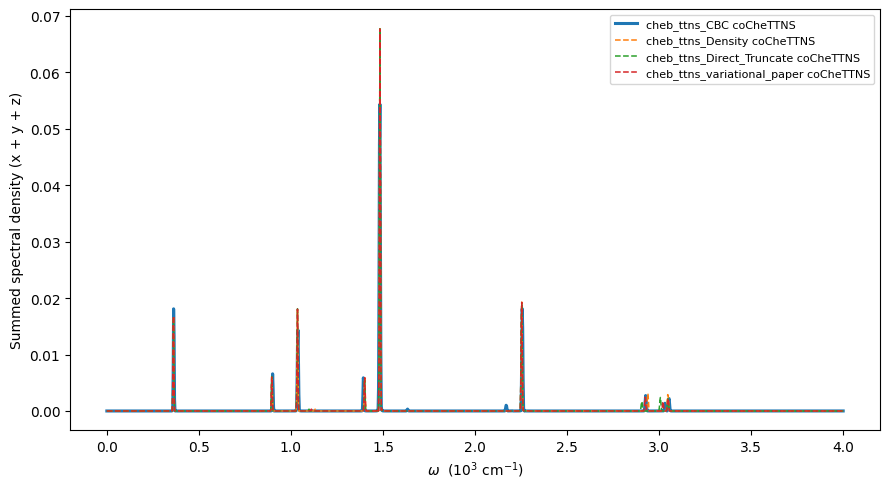

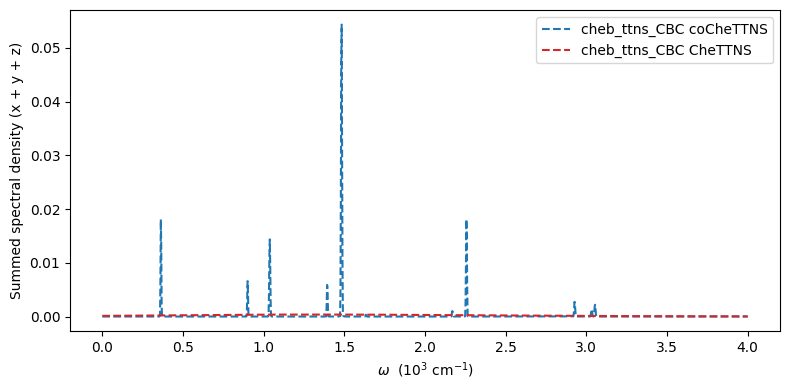

In [67]:
E_max = 4
W_prime = RESCALE_W_PRIME
x_max = E_max / a - W_prime
x_grid = np.linspace(-W_prime, min(0.999, x_max), N_ENERGY_GRID)
E_grid = a * (x_grid + W_prime)

from pathlib import Path
import json

USE_CACHED_CBC_RESULT = bool(globals().get("USE_CACHED_CBC_RESULT", True))
CBC_RESULT_DIR = Path(globals().get(
    "CBC_RESULT_DIR",
    "/Users/link/Desktop/A_Python_code/Chebyshev_upload/Chebyshev/CBC_result",
))


def _load_cached_cbc_runtime(cache_dir):
    runtime_path = cache_dir / "runtime_summary.json"
    if not runtime_path.exists():
        return {}
    rows = json.loads(runtime_path.read_text())
    for row in rows:
        if row.get("method_key") == "cbc" or row.get("method") == "cheb_ttns_CBC":
            return row
    return {}


def _runtime_float(row, key, default=0.0):
    try:
        value = row.get(key, default)
        return float(value) if value not in (None, "") else float(default)
    except (TypeError, ValueError):
        return float(default)


def _interp_cached_spectrum(values, cached_energy_grid, target_energy_grid):
    values = np.asarray(values)
    cached_energy_grid = np.asarray(cached_energy_grid, dtype=np.float64)
    target_energy_grid = np.asarray(target_energy_grid, dtype=np.float64)
    if values.shape == target_energy_grid.shape and np.allclose(cached_energy_grid, target_energy_grid, rtol=0.0, atol=1e-12):
        return values.copy()
    if np.iscomplexobj(values):
        return (
            np.interp(target_energy_grid, cached_energy_grid, values.real)
            + 1j * np.interp(target_energy_grid, cached_energy_grid, values.imag)
        )
    return np.interp(target_energy_grid, cached_energy_grid, values)


def load_cached_cbc_result(cache_dir, target_energy_grid):
    cache_dir = Path(cache_dir)
    arrays_path = cache_dir / "chebyshev_spectrum_data.npz"
    if not arrays_path.exists():
        raise FileNotFoundError(f"Cached CBC Chebyshev data not found: {arrays_path}")

    arrays = np.load(arrays_path, allow_pickle=True)
    required = ["E_grid", "cbc_vals_ttns_eff", "cbc_vals_ttns", "cbc_mu_eff", "cbc_mu"]
    missing = [key for key in required if key not in arrays.files]
    if missing:
        raise KeyError(f"Cached CBC arrays are missing keys: {missing}")

    cached_energy_grid = np.asarray(arrays["E_grid"], dtype=np.float64)
    runtime_row = _load_cached_cbc_runtime(cache_dir)
    timings = {
        "cheb_vector_build_s": _runtime_float(runtime_row, "cheb_vector_s", 0.0),
        "cheb_vector_build_mean_s": _runtime_float(runtime_row, "mean_component_s", np.nan),
        "cheb_Hpsin_total_s": _runtime_float(runtime_row, "Hpsin_total_s", np.nan),
        "cheb_postprocess_total_s": _runtime_float(runtime_row, "postprocess_total_s", np.nan),
        "cheb_psi_np1_total_s": _runtime_float(runtime_row, "psi_np1_total_s", np.nan),
        "heff_s": _runtime_float(runtime_row, "heff_s", 0.0),
        "spectrum_s": 0.0,
    }

    data = {
        "method_key": "cbc",
        "label": "cheb_ttns_CBC",
        "method_enum": ApplicationMethod.HALF_DENSITY_MATRIX,
        "cheb_builder": cheb_ttns_CBC,
        "status": runtime_row.get("status", "ok"),
        "timings": timings,
        "apply_calls": {},
        "cheb_vectors_total": _runtime_float(runtime_row, "vectors_total", np.nan),
        "error": runtime_row.get("error", ""),
        "cached_from": str(cache_dir),
        "cache_energy_grid": cached_energy_grid,
    }

    data["mu"] = np.asarray(arrays["cbc_mu"])
    data["mu_eff"] = np.asarray(arrays["cbc_mu_eff"])
    data["vals_ttns"] = _interp_cached_spectrum(arrays["cbc_vals_ttns"], cached_energy_grid, target_energy_grid)
    data["vals_ttns_eff"] = _interp_cached_spectrum(arrays["cbc_vals_ttns_eff"], cached_energy_grid, target_energy_grid)

    data["mu_by_component"] = {}
    data["mu_eff_by_component"] = {}
    data["vals_ttns_by_component"] = {}
    data["vals_ttns_eff_by_component"] = {}
    for component in DIPOLE_COMPONENTS:
        prefix = f"cbc_{component}"
        if f"{prefix}_mu_direct" in arrays.files:
            data["mu_by_component"][component] = np.asarray(arrays[f"{prefix}_mu_direct"])
        if f"{prefix}_mu_eff" in arrays.files:
            data["mu_eff_by_component"][component] = np.asarray(arrays[f"{prefix}_mu_eff"])
        if f"{prefix}_vals_ttns" in arrays.files:
            data["vals_ttns_by_component"][component] = _interp_cached_spectrum(
                arrays[f"{prefix}_vals_ttns"], cached_energy_grid, target_energy_grid
            )
        if f"{prefix}_vals_ttns_eff" in arrays.files:
            data["vals_ttns_eff_by_component"][component] = _interp_cached_spectrum(
                arrays[f"{prefix}_vals_ttns_eff"], cached_energy_grid, target_energy_grid
            )

    return data


if USE_CACHED_CBC_RESULT:
    cached_cbc_data = load_cached_cbc_result(CBC_RESULT_DIR, E_grid)
    existing_non_cbc_data = {key: value for key, value in contraction_data.items() if key != "cbc"}
    contraction_data.clear()
    contraction_data["cbc"] = cached_cbc_data
    contraction_data.update(existing_non_cbc_data)
    print("Loaded cached CBC Chebyshev data from:", CBC_RESULT_DIR)

spectrum_summary_rows = []
for method_key, data in active_method_items(contraction_data):
    phase = "spectrum reconstruction"
    tic = time.perf_counter()
    try:
        if data.get("cached_from") and "vals_ttns_eff" in data:
            vals_ttns_eff = np.asarray(data["vals_ttns_eff"], dtype=np.float64)
            data["timings"]["spectrum_s"] = 0.0
            spectrum_summary_rows.append({
                "method": data["label"],
                "status": data["status"],
                "spectrum_s": data["timings"]["spectrum_s"],
                "max_eff": float(np.max(vals_ttns_eff.real)),
                "min_eff": float(np.min(vals_ttns_eff.real)),
            })
            continue

        vals_ttns_by_component = {}
        for component in DIPOLE_COMPONENTS:
            vals_ttns_by_component[component] = np.array([
                reconstruct_delta_spectrum(x=x, mu=data["mu_by_component"][component], a=a)
                for x in x_grid
            ])
        vals_ttns = np.sum([vals_ttns_by_component[component] for component in DIPOLE_COMPONENTS], axis=0)

        vals_ttns_eff_by_component = {}
        for component in DIPOLE_COMPONENTS:
            vals_ttns_eff_by_component[component] = np.array([
                reconstruct_delta_spectrum(x=x, mu=data["mu_eff_by_component"][component], a=a)
                for x in x_grid
            ])
        vals_ttns_eff = np.sum([vals_ttns_eff_by_component[component] for component in DIPOLE_COMPONENTS], axis=0)

        data["vals_ttns_by_component"] = vals_ttns_by_component
        data["vals_ttns"] = vals_ttns
        data["vals_ttns_eff_by_component"] = vals_ttns_eff_by_component
        data["vals_ttns_eff"] = vals_ttns_eff
        data["timings"]["spectrum_s"] = time.perf_counter() - tic
        spectrum_summary_rows.append({
            "method": data["label"],
            "status": data["status"],
            "spectrum_s": data["timings"]["spectrum_s"],
            "max_eff": float(np.max(np.asarray(vals_ttns_eff).real)),
            "min_eff": float(np.min(np.asarray(vals_ttns_eff).real)),
        })
    except Exception as exc:
        record_method_error(data, phase, exc)
        spectrum_summary_rows.append({"method": data["label"], "status": data["status"]})
        if STOP_ON_METHOD_ERROR:
            raise

format_table(
    spectrum_summary_rows,
    ["method", "status", "spectrum_s", "max_eff", "min_eff"],
    title="Spectrum reconstruction summary",
)

reference_data = contraction_data.get(REFERENCE_METHOD)
if reference_data is None or reference_data.get("status") != "ok" or "vals_ttns_eff" not in reference_data:
    reference_data = next((data for _, data in active_method_items(contraction_data) if "vals_ttns_eff" in data), None)

comparison_rows = []
if reference_data is not None:
    ref_vals = np.asarray(reference_data["vals_ttns_eff"], dtype=np.float64)
    ref_norm = max(float(np.linalg.norm(ref_vals)), 1e-300)
    for method_key, data in active_method_items(contraction_data):
        if "vals_ttns_eff" not in data:
            continue
        vals = np.asarray(data["vals_ttns_eff"], dtype=np.float64)
        diff = vals - ref_vals
        cheb_vector_s = cheb_vector_runtime_s(data)
        heff_s = heff_runtime_s(data)
        cheb_plus_heff_s = cheb_vector_plus_heff_runtime_s(data)
        comparison_rows.append({
            "method": data["label"],
            "reference": reference_data["label"],
            "cheb_vector_s": cheb_vector_s,
            "heff_s": heff_s,
            "cheb_plus_heff_s": cheb_plus_heff_s,
            "mean_component_s": data.get("timings", {}).get("cheb_vector_build_mean_s", np.nan),
            "vectors_each": CHEB_TTNS_BASIS_SIZE,
            "rel_l2_vs_ref": float(np.linalg.norm(diff) / ref_norm),
            "max_abs_vs_ref": float(np.max(np.abs(diff))),
            "mean_abs_vs_ref": float(np.mean(np.abs(diff))),
        })

format_table(
    comparison_rows,
    ["method", "reference", "cheb_vector_s", "heff_s", "cheb_plus_heff_s", "mean_component_s", "vectors_each", "rel_l2_vs_ref", "max_abs_vs_ref", "mean_abs_vs_ref"],
    title="Contraction method comparison vs reference spectrum (time = 125 Chebyshev vectors + Heff)",
)

plt.figure(figsize=(9, 5))
for method_key, data in active_method_items(contraction_data):
    if "vals_ttns_eff" not in data:
        continue
    linewidth = 2.2 if data is reference_data else 1.1
    linestyle = "-" if data is reference_data else "--"
    plt.plot(E_grid, data["vals_ttns_eff"], linewidth=linewidth, linestyle=linestyle, label=f"{data['label']} coCheTTNS")
plt.xlabel(r"$\omega$  $(10^3\ \mathrm{cm}^{-1})$")
plt.ylabel("Summed spectral density (x + y + z)")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

if reference_data is not None:
    plt.figure(figsize=(8, 4))
    plt.plot(E_grid, reference_data["vals_ttns_eff"], color="tab:blue", linestyle="--", label=f"{reference_data['label']} coCheTTNS")
    plt.plot(E_grid, reference_data["vals_ttns"], color="tab:red", linestyle="--", label=f"{reference_data['label']} CheTTNS")
    plt.xlabel(r"$\omega$  $(10^3\ \mathrm{cm}^{-1})$")
    plt.ylabel("Summed spectral density (x + y + z)")
    plt.legend()
    plt.tight_layout()
    plt.show()


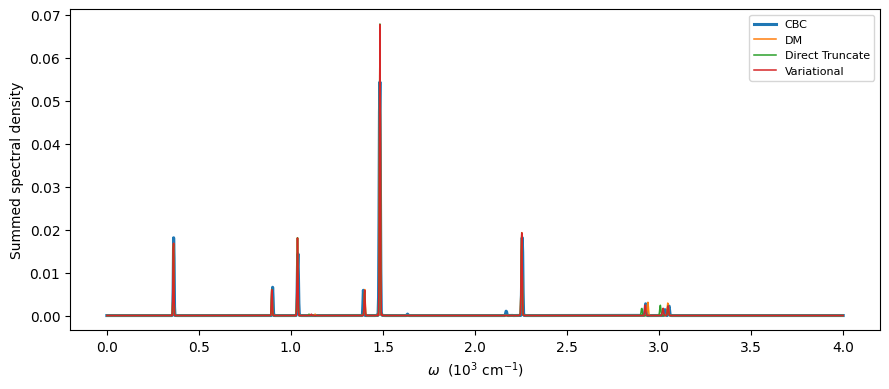

In [68]:
# Plot the summed x/y/z coCheTTNS spectrum for each contraction method.
# CBC is read directly from CBC_RESULT_DIR; the other methods use the current
# kernel's already-computed contraction_data, so this cell does not rerun them.
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

CBC_RESULT_DIR = Path(globals().get(
    "CBC_RESULT_DIR",
    "/Users/link/Desktop/A_Python_code/Chebyshev_upload/Chebyshev/CBC_result",
))

METHOD_DISPLAY_LABELS = {
    "cheb_ttns_CBC": "CBC",
    "cheb_ttns_Density": "DM",
    "cheb_ttns_Direct_Truncate": "Direct Truncate",
    "cheb_ttns_variational_paper": "Variational",
}


def display_method_label(method):
    return METHOD_DISPLAY_LABELS.get(
        str(method),
        str(method).removeprefix("cheb_ttns_").replace("_", " "),
    )


def load_cached_cbc_spectrum(cache_dir):
    arrays_path = Path(cache_dir) / "chebyshev_spectrum_data.npz"
    if not arrays_path.exists():
        raise FileNotFoundError(f"Cached CBC spectrum not found: {arrays_path}")
    arrays = np.load(arrays_path, allow_pickle=True)
    e_key = "E_grid" if "E_grid" in arrays.files else "energy_grid"
    vals_key = "cbc_vals_ttns_eff" if "cbc_vals_ttns_eff" in arrays.files else "vals_ttns_eff"
    return (
        np.asarray(arrays[e_key], dtype=np.float64),
        np.asarray(arrays[vals_key], dtype=np.float64),
        arrays_path,
    )


def iter_non_cbc_method_items():
    if "contraction_data" not in globals():
        return []
    if "active_method_items" in globals():
        items = list(active_method_items(contraction_data))
    else:
        items = list(contraction_data.items())
    ordered_keys = ["density", "direct_truncate", "variational_paper"]
    order = {key: i for i, key in enumerate(ordered_keys)}
    items = sorted(items, key=lambda item: order.get(item[0], len(order)))
    return [
        (method_key, data)
        for method_key, data in items
        if method_key != "cbc" and data.get("label") != "cheb_ttns_CBC"
    ]

plt.figure(figsize=(9, 4))

cbc_E_grid, cbc_vals_ttns_eff, cbc_arrays_path = load_cached_cbc_spectrum(CBC_RESULT_DIR)
plt.plot(cbc_E_grid, cbc_vals_ttns_eff, linewidth=2.2, label="CBC")

for method_key, data in iter_non_cbc_method_items():
    vals = data.get("vals_ttns_eff")
    if vals is None:
        continue
    plt.plot(
        E_grid,
        np.asarray(vals, dtype=np.float64),
        linewidth=1.1,
        label=display_method_label(data.get("label", method_key)),
    )

plt.xlabel(r"$\omega$  $(10^3\ \mathrm{cm}^{-1})$")
plt.ylabel("Summed spectral density")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()


### Summed x/y/z peak area analysis



Visible broadened maxima for cheb_ttns_CBC (x + y + z)
peak  peak_E    height       left      right     grid_area    two_grid_area
----  --------  -----------  --------  --------  -----------  -------------
1     0.362727  0.018101     0         0.550344  0.000100785  0.000201569  
2     0.900563  0.0065835    0.550344  0.955597  3.8844e-05   7.76879e-05  
3     1.03815   0.0143613    0.955597  1.20075   0.0001087    0.0002174    
4     1.39337   0.00587893   1.20075   1.42339   3.93793e-05  7.87586e-05  
5     1.48343   0.0543559    1.42339   1.5985    0.000435888  0.000871776  
6     1.63352   0.000336802  1.5985    1.98124   2.21965e-06  4.43931e-06  
7     2.16886   0.00101685   1.98124   2.18386   7.45954e-06  1.49191e-05  
8     2.25641   0.0181125    2.18386   2.5591    0.000131366  0.000262732  
9     2.92683   0.00273779   2.5591    2.97436   2.12105e-05  4.2421e-05   
10    3.03189   0.00137236   2.97436   3.0444    1.08899e-05  2.17798e-05  
11    3.05441   0.00219176   3.0

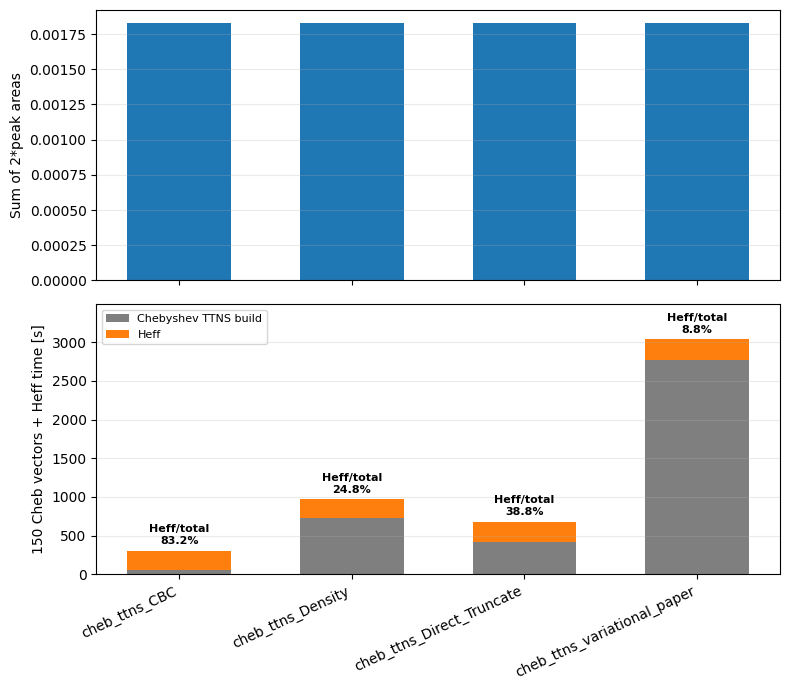

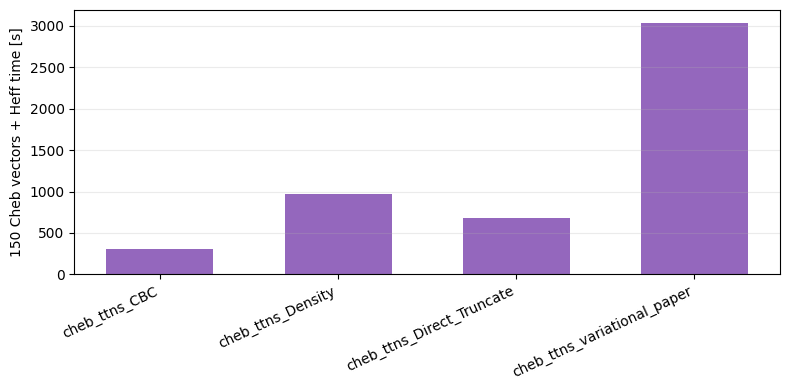

Unmatched reference peaks for cheb_ttns_Density: [5, 6, 9]
Unmatched reference peaks for cheb_ttns_Direct_Truncate: [5, 6]
Unmatched reference peaks for cheb_ttns_variational_paper: [5, 6]

Peak comparison vs reference contraction method
method                       reference      match  ref_peak  peak  ref_peak_E  peak_E    delta_peak_E  ref_two_area  two_area     delta_two_area  ratio_area
---------------------------  -------------  -----  --------  ----  ----------  --------  ------------  ------------  -----------  --------------  ----------
cheb_ttns_CBC                cheb_ttns_CBC  1      1         1     0.362727    0.362727  0             0.000201569   0.000201569  0               1         
cheb_ttns_CBC                cheb_ttns_CBC  2      2         2     0.900563    0.900563  0             7.76879e-05   7.76879e-05  0               1         
cheb_ttns_CBC                cheb_ttns_CBC  3      3         3     1.03815     1.03815   0             0.0002174     0.0002174    0   

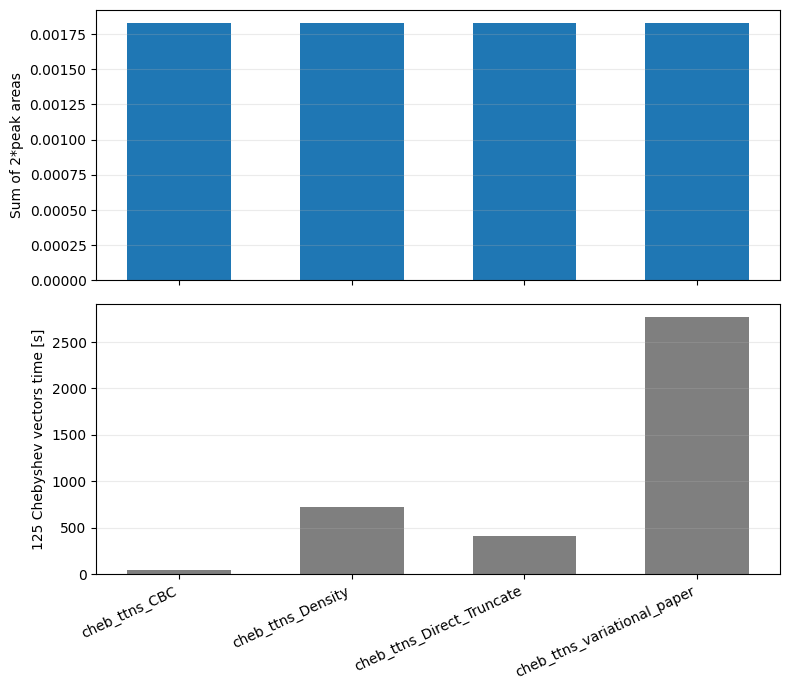

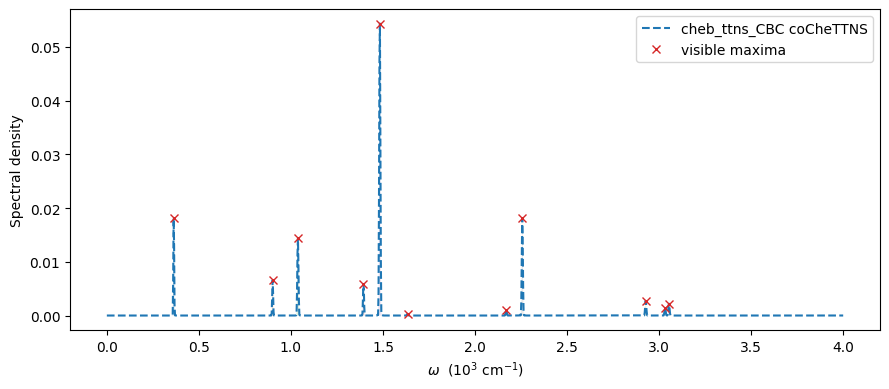

In [69]:
# Detect visible broadened maxima and integrate local areas of the summed
# spectrum vals_x + vals_y + vals_z for every contraction method.
PEAK_PROMINENCE_REL = 0.005
PEAK_MIN_DISTANCE = 0.015  # in 10^3 cm^-1 units
PEAK_MATCH_TOLERANCE = 0.08  # in 10^3 cm^-1 units


def detect_visible_peak_areas(vals, energy_grid, label):
    vals_area = np.clip(np.asarray(vals, dtype=np.float64), 0.0, None)
    if np.max(vals_area) <= 0:
        raise RuntimeError(f"The summed coCheTTNS spectrum for {label} is non-positive on the plotting grid.")

    dE = float(np.mean(np.diff(energy_grid)))
    min_distance_points = max(1, int(round(PEAK_MIN_DISTANCE / max(dE, 1e-15))))
    prominence = PEAK_PROMINENCE_REL * float(np.max(vals_area))
    peak_idx, peak_props = find_peaks(vals_area, prominence=prominence, distance=min_distance_points)

    if len(peak_idx) == 0:
        raise RuntimeError(f"No peaks found for {label}. Lower PEAK_PROMINENCE_REL or check the spectrum plot.")

    peak_idx = peak_idx[np.argsort(energy_grid[peak_idx])]
    boundary_idx = [0]
    for left_peak, right_peak in zip(peak_idx[:-1], peak_idx[1:]):
        segment = vals_area[left_peak:right_peak + 1]
        boundary_idx.append(left_peak + int(np.argmin(segment)))
    boundary_idx.append(len(energy_grid) - 1)

    rows = []
    for i, pidx in enumerate(peak_idx):
        left_i = boundary_idx[i]
        right_i = boundary_idx[i + 1]
        if right_i <= left_i:
            right_i = min(left_i + 1, len(energy_grid) - 1)

        local_E = energy_grid[left_i:right_i + 1]
        local_vals = vals_area[left_i:right_i + 1]
        area = float(np.trapezoid(local_vals, local_E)) if len(local_E) >= 2 else np.nan
        rows.append({
            "peak": i + 1,
            "peak_E": float(energy_grid[pidx]),
            "height": float(vals_area[pidx]),
            "left": float(energy_grid[left_i]),
            "right": float(energy_grid[right_i]),
            "grid_area": area,
            "two_grid_area": 2.0 * area if np.isfinite(area) else np.nan,
        })

    return rows, boundary_idx, vals_area, prominence, min_distance_points


def match_peak_rows(reference_rows, method_rows, tolerance):
    candidates = []
    for i, ref_row in enumerate(reference_rows):
        for j, row in enumerate(method_rows):
            delta = abs(ref_row["peak_E"] - row["peak_E"])
            if delta <= tolerance:
                candidates.append((delta, i, j))
    candidates.sort(key=lambda item: item[0])

    used_ref = set()
    used_method = set()
    matches = []
    for delta, i, j in candidates:
        if i in used_ref or j in used_method:
            continue
        used_ref.add(i)
        used_method.add(j)
        matches.append((i, j, delta))
    matches.sort(key=lambda item: reference_rows[item[0]]["peak_E"])
    unmatched_ref = [i for i in range(len(reference_rows)) if i not in used_ref]
    unmatched_method = [j for j in range(len(method_rows)) if j not in used_method]
    return matches, unmatched_ref, unmatched_method

area_rows_by_method = {}
peak_diagnostics_by_method = {}
peak_summary_rows = []

for method_key, data in active_method_items(contraction_data):
    if "vals_ttns_eff" not in data:
        continue
    phase = "peak area analysis"
    try:
        rows, boundary_idx, vals_area, prominence, min_distance_points = detect_visible_peak_areas(
            data["vals_ttns_eff"],
            E_grid,
            data["label"],
        )
        area_rows_by_method[method_key] = rows
        peak_diagnostics_by_method[method_key] = {
            "boundary_idx": boundary_idx,
            "vals_area": vals_area,
            "prominence": prominence,
            "min_distance_points": min_distance_points,
        }
        total_two_area = float(np.nansum([row["two_grid_area"] for row in rows]))
        peak_summary_rows.append({
            "method": data["label"],
            "peaks": len(rows),
            "sum_two_area": total_two_area,
            "prominence": prominence,
            "min_distance_points": min_distance_points,
        })
        print(f"\nVisible broadened maxima for {data['label']} (x + y + z)")
        format_table(rows, ["peak", "peak_E", "height", "left", "right", "grid_area", "two_grid_area"])
    except Exception as exc:
        record_method_error(data, phase, exc)
        if STOP_ON_METHOD_ERROR:
            raise

format_table(
    peak_summary_rows,
    ["method", "peaks", "sum_two_area", "prominence", "min_distance_points"],
    title="Peak area summary by contraction method",
)

reference_key = REFERENCE_METHOD if REFERENCE_METHOD in area_rows_by_method else next(iter(area_rows_by_method), None)
peak_comparison_rows = []
if reference_key is not None:
    ref_rows = area_rows_by_method[reference_key]
    ref_label = contraction_data[reference_key]["label"]
    for method_key, rows in area_rows_by_method.items():
        matches, unmatched_ref, unmatched_method = match_peak_rows(ref_rows, rows, PEAK_MATCH_TOLERANCE)
        for match_index, (i, j, abs_delta_peak_E) in enumerate(matches, start=1):
            ref_row = ref_rows[i]
            row = rows[j]
            ref_area = ref_row["two_grid_area"]
            area = row["two_grid_area"]
            peak_comparison_rows.append({
                "method": contraction_data[method_key]["label"],
                "reference": ref_label,
                "match": match_index,
                "ref_peak": ref_row["peak"],
                "peak": row["peak"],
                "ref_peak_E": ref_row["peak_E"],
                "peak_E": row["peak_E"],
                "delta_peak_E": row["peak_E"] - ref_row["peak_E"],
                "ref_two_area": ref_area,
                "two_area": area,
                "delta_two_area": area - ref_area,
                "ratio_area": area / ref_area if ref_area != 0 else np.nan,
            })
        if unmatched_ref:
            print(f"Unmatched reference peaks for {contraction_data[method_key]['label']}:", unmatched_ref)
        if unmatched_method:
            print(f"Unmatched method peaks for {contraction_data[method_key]['label']}:", unmatched_method)

format_table(
    peak_comparison_rows,
    ["method", "reference", "match", "ref_peak", "peak", "ref_peak_E", "peak_E", "delta_peak_E", "ref_two_area", "two_area", "delta_two_area", "ratio_area"],
    title="Peak comparison vs reference contraction method",
)

if peak_summary_rows:
    plot_method_keys = [
        method_key
        for method_key, data in active_method_items(contraction_data)
        if method_key in area_rows_by_method
    ]
    method_labels = [contraction_data[method_key]["label"] for method_key in plot_method_keys]
    total_areas = np.array([
        np.nansum([row["two_grid_area"] for row in area_rows_by_method[method_key]])
        for method_key in plot_method_keys
    ], dtype=np.float64)
    cheb_runtimes = np.array([
        cheb_vector_runtime_s(contraction_data[method_key])
        for method_key in plot_method_keys
    ], dtype=np.float64)
    heff_runtimes = np.array([
        heff_runtime_s(contraction_data[method_key])
        for method_key in plot_method_keys
    ], dtype=np.float64)
    runtimes_with_heff = cheb_runtimes + heff_runtimes
    heff_runtime_fraction = np.divide(
        heff_runtimes,
        runtimes_with_heff,
        out=np.full_like(heff_runtimes, np.nan),
        where=runtimes_with_heff > 0.0,
    )
    x = np.arange(len(method_labels))

    fig, (ax_area, ax_time) = plt.subplots(2, 1, figsize=(max(8, 1.2 * len(method_labels)), 7), sharex=True)
    ax_area.bar(x, total_areas, width=0.6)
    ax_area.set_ylabel("Sum of 2*peak areas")
    ax_area.grid(True, axis="y", alpha=0.25)

    ax_time.bar(x, cheb_runtimes, width=0.6, color="tab:gray", label="Chebyshev TTNS build")
    ax_time.bar(x, heff_runtimes, width=0.6, bottom=cheb_runtimes, color="tab:orange", label="Heff")
    if np.any(np.isfinite(runtimes_with_heff)):
        label_pad = 0.02 * float(np.nanmax(runtimes_with_heff))
        for x_pos, total_s, fraction in zip(x, runtimes_with_heff, heff_runtime_fraction):
            if not np.isfinite(total_s) or not np.isfinite(fraction):
                continue
            ax_time.text(
                x_pos,
                total_s + label_pad,
                f"Heff/total\n{fraction:.1%}",
                ha="center",
                va="bottom",
                fontsize=8,
                fontweight="semibold",
            )
        ax_time.set_ylim(top=float(np.nanmax(runtimes_with_heff)) * 1.15)
    ax_time.set_ylabel("150 Cheb vectors + Heff time [s]")
    ax_time.set_xticks(x)
    ax_time.set_xticklabels(method_labels, rotation=25, ha="right")
    ax_time.grid(True, axis="y", alpha=0.25)
    ax_time.legend(fontsize=8)
    fig.tight_layout()
    plt.show()

    fig_time, ax_time_total = plt.subplots(figsize=(max(8, 1.2 * len(method_labels)), 4))
    ax_time_total.bar(x, runtimes_with_heff, width=0.6, color="tab:purple")
    ax_time_total.set_ylabel("150 Cheb vectors + Heff time [s]")
    ax_time_total.set_xticks(x)
    ax_time_total.set_xticklabels(method_labels, rotation=25, ha="right")
    ax_time_total.grid(True, axis="y", alpha=0.25)
    fig_time.tight_layout()
    plt.show()

if reference_key is not None:
    ref_rows = area_rows_by_method[reference_key]
    ref_label = contraction_data[reference_key]["label"]
    for method_key, rows in area_rows_by_method.items():
        matches, unmatched_ref, unmatched_method = match_peak_rows(ref_rows, rows, PEAK_MATCH_TOLERANCE)
        for match_index, (i, j, abs_delta_peak_E) in enumerate(matches, start=1):
            ref_row = ref_rows[i]
            row = rows[j]
            ref_area = ref_row["two_grid_area"]
            area = row["two_grid_area"]
            peak_comparison_rows.append({
                "method": contraction_data[method_key]["label"],
                "reference": ref_label,
                "match": match_index,
                "ref_peak": ref_row["peak"],
                "peak": row["peak"],
                "ref_peak_E": ref_row["peak_E"],
                "peak_E": row["peak_E"],
                "delta_peak_E": row["peak_E"] - ref_row["peak_E"],
                "ref_two_area": ref_area,
                "two_area": area,
                "delta_two_area": area - ref_area,
                "ratio_area": area / ref_area if ref_area != 0 else np.nan,
            })
        if unmatched_ref:
            print(f"Unmatched reference peaks for {contraction_data[method_key]['label']}:", unmatched_ref)
        if unmatched_method:
            print(f"Unmatched method peaks for {contraction_data[method_key]['label']}:", unmatched_method)

format_table(
    peak_comparison_rows,
    ["method", "reference", "match", "ref_peak", "peak", "ref_peak_E", "peak_E", "delta_peak_E", "ref_two_area", "two_area", "delta_two_area", "ratio_area"],
    title="Peak comparison vs reference contraction method",
)

if peak_summary_rows:
    method_labels = [row["method"] for row in peak_summary_rows]
    total_areas = np.array([row["sum_two_area"] for row in peak_summary_rows], dtype=np.float64)
    runtimes = []
    for method_key, data in active_method_items(contraction_data):
        if method_key in area_rows_by_method:
            runtimes.append(cheb_vector_runtime_s(data))
    x = np.arange(len(method_labels))

    fig, (ax_area, ax_time) = plt.subplots(2, 1, figsize=(max(8, 1.2 * len(method_labels)), 7), sharex=True)
    ax_area.bar(x, total_areas, width=0.6)
    ax_area.set_ylabel("Sum of 2*peak areas")
    ax_area.grid(True, axis="y", alpha=0.25)

    ax_time.bar(x, runtimes, width=0.6, color="tab:gray")
    ax_time.set_ylabel("125 Chebyshev vectors time [s]")
    ax_time.set_xticks(x)
    ax_time.set_xticklabels(method_labels, rotation=25, ha="right")
    ax_time.grid(True, axis="y", alpha=0.25)
    fig.tight_layout()
    plt.show()

if reference_key is not None:
    ref_diag = peak_diagnostics_by_method[reference_key]
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(E_grid, ref_diag["vals_area"], color="tab:blue", linestyle="--", label=f"{contraction_data[reference_key]['label']} coCheTTNS")
    for left_i, right_i in zip(ref_diag["boundary_idx"][:-1], ref_diag["boundary_idx"][1:]):
        ax.fill_between(E_grid[left_i:right_i + 1], ref_diag["vals_area"][left_i:right_i + 1], alpha=0.16)
    ax.plot(
        [row["peak_E"] for row in area_rows_by_method[reference_key]],
        [row["height"] for row in area_rows_by_method[reference_key]],
        "x",
        color="tab:red",
        label="visible maxima",
    )
    ax.set_xlabel(r"$\omega$  $(10^3\ \mathrm{cm}^{-1})$")
    ax.set_ylabel("Spectral density")
    ax.legend()
    fig.tight_layout()
    plt.show()


### Final method status


In [70]:
status_rows = []
for method_key, data in contraction_data.items():
    timings = data.get("timings", {})
    cheb_vector_s = cheb_vector_runtime_s(data)
    heff_s = heff_runtime_s(data)
    status_rows.append({
        "method": data["label"],
        "status": data.get("status", "unknown"),
        "cheb_vector_s": cheb_vector_s,
        "heff_s": heff_s,
        "cheb_plus_heff_s": cheb_vector_s + heff_s,
        "mean_component_s": timings.get("cheb_vector_build_mean_s", np.nan),
        "vectors_each": CHEB_TTNS_BASIS_SIZE,
        "vectors_total": data.get("cheb_vectors_total", np.nan),
        "Hpsin_total_s": timings.get("cheb_Hpsin_total_s", np.nan),
        "postprocess_total_s": timings.get("cheb_postprocess_total_s", np.nan),
        "psi_np1_total_s": timings.get("cheb_psi_np1_total_s", np.nan),
        "error": data.get("error", ""),
    })

format_table(
    status_rows,
    [
        "method",
        "status",
        "cheb_vector_s",
        "heff_s",
        "cheb_plus_heff_s",
        "mean_component_s",
        "vectors_each",
        "vectors_total",
        "Hpsin_total_s",
        "postprocess_total_s",
        "psi_np1_total_s",
        "error",
    ],
    title="Final contraction method status (time = full Chebyshev TTNS build + Heff)",
)

failed = [data for data in contraction_data.values() if data.get("status") != "ok"]
if failed:
    print("\nFailed method tracebacks are stored in contraction_data[method_key]['traceback'].")



Final contraction method status (time = full Chebyshev TTNS build + Heff)
method                       status  cheb_vector_s  heff_s   cheb_plus_heff_s  mean_component_s  vectors_each  vectors_total  Hpsin_total_s  postprocess_total_s  psi_np1_total_s  error
---------------------------  ------  -------------  -------  ----------------  ----------------  ------------  -------------  -------------  -------------------  ---------------  -----
cheb_ttns_CBC                ok      51.3477        255.15   306.497           17.1159           125           375            49.2205        0.0132017            2.11114               
cheb_ttns_Density            ok      728.203        240.13   968.334           242.734           125           375            725.473        0.0114427            2.67037               
cheb_ttns_Direct_Truncate    ok      417.181        264.521  681.702           139.06            125           375            10.499         2.62158              404.031               


### Dipole spectral function


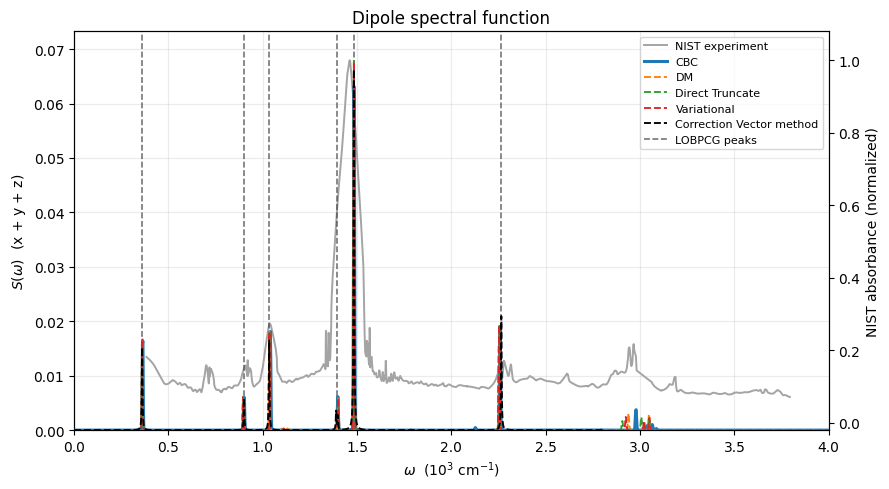

NIST experiment CSV: /Users/link/Desktop/A_Python_code/Chebyshev_upload/Chebyshev/CH3CN_NIST_experimental_IR_spectrum.csv
Chebyshev spectrum cache for non-CBC curves: /Users/link/Desktop/A_Python_code/Chebyshev_upload/Chebyshev/CH3CN_T3NS_12dim_125N_mu0_real_summed_spectral_density_for_NIST_comparison.npz
New CBC spectrum cache: /Users/link/Desktop/A_Python_code/Chebyshev_upload/Chebyshev/CBC_result/chebyshev_spectrum_data.npz
LOBPCG spectral function: /Users/link/Desktop/A_Python_code/Chebyshev_upload/Chebyshev/master_thesis_reference/threetree/max_bond_dim_12/lobpcg_150_dipole_spectral_function.csv
Saved PDF: /Users/link/Desktop/A_Python_code/Chebyshev_upload/Chebyshev/CH3CN_T3NS_12dim_125N_mu0_real_dipole_spectral_function_with_lobpcg150.pdf
Saved PNG: /Users/link/Desktop/A_Python_code/Chebyshev_upload/Chebyshev/CH3CN_T3NS_12dim_125N_mu0_real_dipole_spectral_function_with_lobpcg150.png


In [2]:
# Final dipole spectral function plot with NIST experiment and the 150-state
# LOBPCG spectral function. This cell is intentionally self-contained: it reads
# cached plotting data and does not require re-running earlier contraction cells.
from pathlib import Path
import csv

import numpy as np
import matplotlib.pyplot as plt

ROOT = Path("/Users/link/Desktop/A_Python_code/Chebyshev_upload/Chebyshev")
CHEB_SPECTRUM_NPZ = ROOT / "CH3CN_T3NS_12dim_125N_mu0_real_summed_spectral_density_for_NIST_comparison.npz"
NIST_CSV_PATH = ROOT / "CH3CN_NIST_experimental_IR_spectrum.csv"
CBC_RESULT_DIR = ROOT / "CBC_result"
CBC_SPECTRUM_NPZ = CBC_RESULT_DIR / "chebyshev_spectrum_data.npz"
LOBPCG_SPECTRUM_CSV = ROOT / "master_thesis_reference/threetree/max_bond_dim_12/lobpcg_150_dipole_spectral_function.csv"
LOBPCG_MERGED_PEAKS_CSV = ROOT / "master_thesis_reference/threetree/max_bond_dim_12/lobpcg_150_final_ir_merged_delta_pole_areas.csv"
OUTPUT_PDF = ROOT / "CH3CN_T3NS_12dim_125N_mu0_real_dipole_spectral_function_with_lobpcg150.pdf"
OUTPUT_PNG = OUTPUT_PDF.with_suffix(".png")

LOBPCG_SCALE = 1.0

METHOD_COLUMNS = [
    ("CBC", "CBC", {"linewidth": 2.2, "linestyle": "-", "color": "tab:blue"}),
    ("DM", "DM", {"linewidth": 1.35, "linestyle": "--", "color": "tab:orange"}),
    ("Direct_Truncate", "Direct Truncate", {"linewidth": 1.35, "linestyle": "--", "color": "tab:green"}),
    ("Variational", "Variational", {"linewidth": 1.35, "linestyle": "--", "color": "tab:red"}),
]


def require_file(path: Path) -> Path:
    path = Path(path)
    if not path.is_file():
        raise FileNotFoundError(path)
    return path


def load_lobpcg_spectrum(path: Path) -> tuple[np.ndarray, np.ndarray]:
    data = np.genfromtxt(require_file(path), delimiter=",", names=True)
    names = set(data.dtype.names or ())
    if "omega_1000cm" not in names or "S_total" not in names:
        raise KeyError(f"{path} must contain omega_1000cm and S_total columns")
    return np.asarray(data["omega_1000cm"], dtype=np.float64), np.asarray(data["S_total"], dtype=np.float64)


def load_lobpcg_peak_markers(path: Path, fallback: np.ndarray) -> np.ndarray:
    path = Path(path)
    if not path.is_file():
        return np.asarray(fallback, dtype=np.float64)
    with open(path, newline="") as handle:
        reader = csv.DictReader(handle)
        if "peak_E" not in (reader.fieldnames or []):
            return np.asarray(fallback, dtype=np.float64)
        values = [float(row["peak_E"]) for row in reader if row.get("peak_E", "")]
    if not values:
        return np.asarray(fallback, dtype=np.float64)
    return np.asarray(values, dtype=np.float64)


def load_new_cbc_spectrum(path: Path) -> tuple[np.ndarray, np.ndarray]:
    with np.load(require_file(path), allow_pickle=True) as data:
        if "E_grid" not in data.files or "cbc_vals_ttns_eff" not in data.files:
            raise KeyError(f"{path} must contain E_grid and cbc_vals_ttns_eff")
        return (
            np.asarray(data["E_grid"], dtype=np.float64),
            np.real_if_close(np.asarray(data["cbc_vals_ttns_eff"]), tol=1000).astype(np.float64),
        )


def load_nist_experiment(path: Path) -> tuple[np.ndarray, np.ndarray]:
    data = np.genfromtxt(require_file(path), delimiter=",", names=True)
    names = set(data.dtype.names or ())
    required = {"wavenumber_cm_minus_1", "absorbance"}
    if not required.issubset(names):
        raise KeyError(f"{path} must contain {sorted(required)} columns")
    wavenumber = np.asarray(data["wavenumber_cm_minus_1"], dtype=np.float64)
    absorbance = np.asarray(data["absorbance"], dtype=np.float64)
    finite = np.isfinite(wavenumber) & np.isfinite(absorbance)
    wavenumber = wavenumber[finite]
    absorbance = np.clip(absorbance[finite], 0.0, None)
    max_absorbance = float(np.nanmax(absorbance))
    if max_absorbance <= 0.0:
        raise ValueError(f"{path} has no positive absorbance values")
    return wavenumber / 1000.0, absorbance / max_absorbance


cheb_data = np.load(require_file(CHEB_SPECTRUM_NPZ), allow_pickle=True)
energy_grid = np.asarray(cheb_data["energy_1000_cm"], dtype=np.float64)
nist_energy, nist_norm = load_nist_experiment(NIST_CSV_PATH)
cbc_energy_grid, cbc_spectral_total = load_new_cbc_spectrum(CBC_SPECTRUM_NPZ)
lobpcg_peak_markers = load_lobpcg_peak_markers(
    LOBPCG_MERGED_PEAKS_CSV,
    np.asarray(cheb_data["LOBPCG_peak_markers_1000_cm"], dtype=np.float64),
)
lobpcg_energy, lobpcg_spectral_total = load_lobpcg_spectrum(LOBPCG_SPECTRUM_CSV)

fig, ax = plt.subplots(figsize=(9, 5))
ax2 = ax.twinx()

# The experimental trace uses its own normalized right axis, so the calculated
# spectral-function scale on the left axis stays unchanged.
ax2.plot(
    nist_energy,
    nist_norm,
    color="0.35",
    linewidth=1.4,
    alpha=0.55,
    label="NIST experiment",
    zorder=1.0,
)
ax.set_zorder(ax2.get_zorder() + 1)
ax.patch.set_visible(False)

for key, label, style in METHOD_COLUMNS:
    plot_style = dict(style)
    plot_style.setdefault("zorder", 3.0)
    if key == "CBC":
        ax.plot(cbc_energy_grid, cbc_spectral_total, label=label, **plot_style)
        continue
    if key not in cheb_data.files:
        print(f"Skipping missing cached curve: {key}")
        continue
    ax.plot(energy_grid, np.asarray(cheb_data[key], dtype=np.float64), label=label, **plot_style)

ax.plot(
    lobpcg_energy,
    LOBPCG_SCALE * lobpcg_spectral_total,
    color="black",
    linewidth=1.35,
    linestyle="--",
    label="Correction Vector method",
    zorder=3.2,
)

for marker_index, peak_E in enumerate(lobpcg_peak_markers):
    ax.axvline(
        float(peak_E),
        color="0.25",
        linestyle="--",
        linewidth=1.15,
        alpha=0.75,
        label="LOBPCG peaks" if marker_index == 0 else "_nolegend_",
        zorder=2.0,
    )

ax.set_title("Dipole spectral function")
ax.set_xlabel(r"$\omega$  $(10^3\ \mathrm{cm}^{-1})$")
ax.set_ylabel(r"$S(\omega)$  (x + y + z)")
ax2.set_ylabel("NIST absorbance (normalized)")
ax.set_xlim(0.0, 4.0)
ax2.set_ylim(-0.02, 1.08)

ymax = float(np.nanmax(cbc_spectral_total))
for key, _, _ in METHOD_COLUMNS:
    if key != "CBC" and key in cheb_data.files:
        ymax = max(ymax, float(np.nanmax(np.asarray(cheb_data[key], dtype=np.float64))))
ymax = max(ymax, float(np.nanmax(LOBPCG_SCALE * lobpcg_spectral_total)))
if ymax > 0.0:
    ax.set_ylim(0.0, ymax * 1.08)

handles1, labels1 = ax.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax.legend(handles2 + handles1, labels2 + labels1, fontsize=8, loc="upper right")
ax.grid(True, alpha=0.25)
fig.tight_layout()
fig.savefig(OUTPUT_PDF, bbox_inches="tight")
fig.savefig(OUTPUT_PNG, dpi=220, bbox_inches="tight")
plt.show()

print("NIST experiment CSV:", NIST_CSV_PATH)
print("Chebyshev spectrum cache for non-CBC curves:", CHEB_SPECTRUM_NPZ)
print("New CBC spectrum cache:", CBC_SPECTRUM_NPZ)
print("LOBPCG spectral function:", LOBPCG_SPECTRUM_CSV)
print("Saved PDF:", OUTPUT_PDF)
print("Saved PNG:", OUTPUT_PNG)


### Peak area errors vs LOBPCG reference


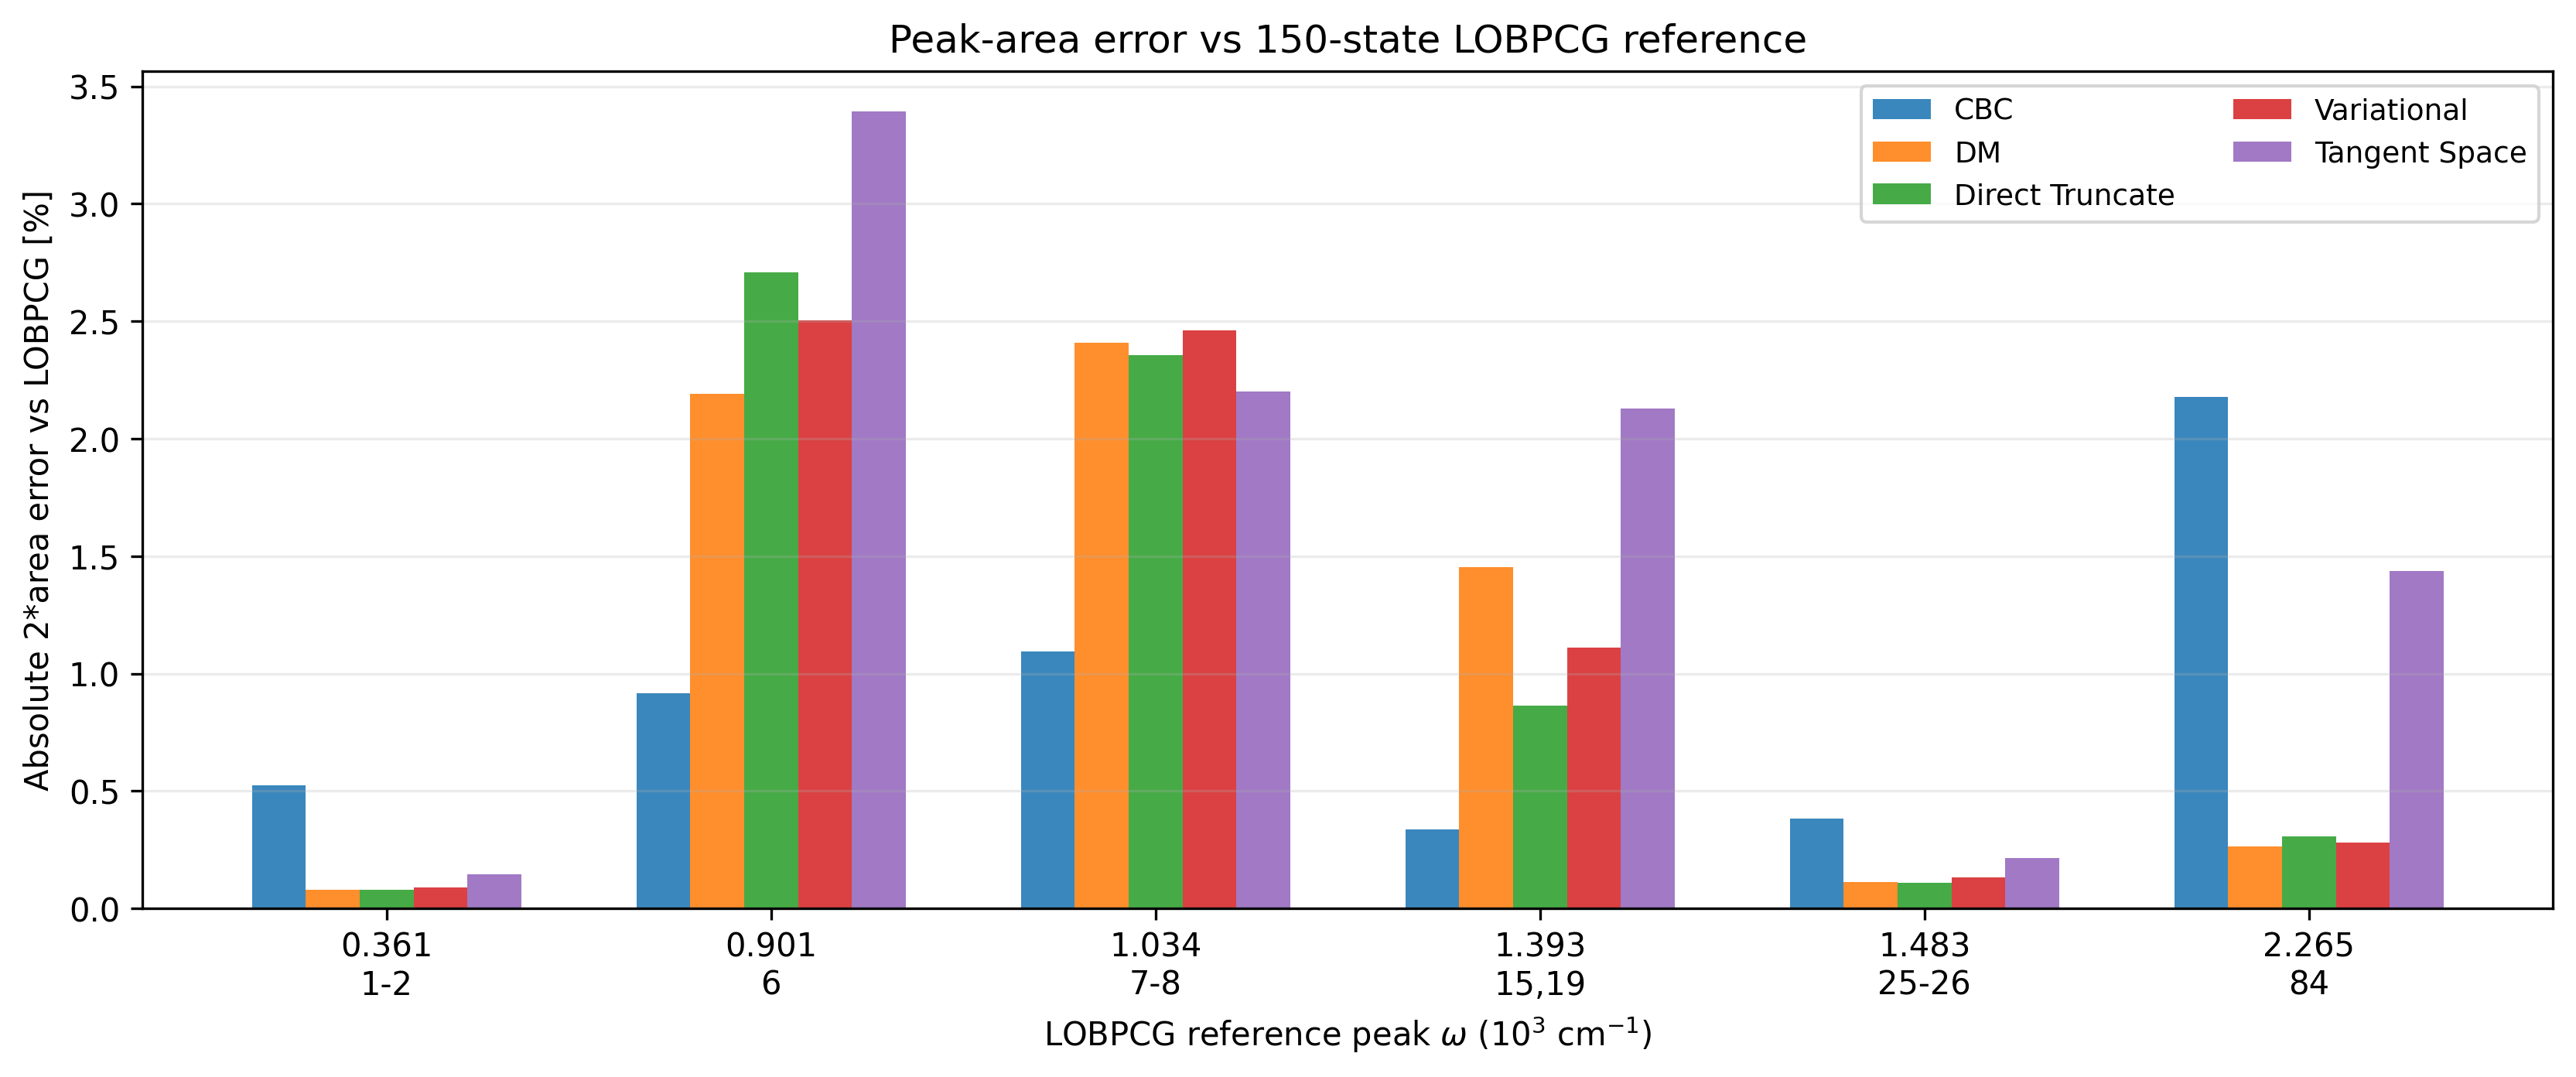

In [ ]:
# --- PEAK_AREA_ERROR_VS_LOBPCG150_START ---
# Self-contained comparison against the 150-state three-tree LOBPCG reference.
# This reads cached spectra and reference CSV files only; it does not rerun contractions.
from pathlib import Path
import csv

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

ROOT = Path("/Users/link/Desktop/A_Python_code/Chebyshev_upload/Chebyshev")
REFERENCE_DIR = ROOT / "master_thesis_reference" / "threetree" / "max_bond_dim_12"
CHEB_SPECTRUM_NPZ = ROOT / "CH3CN_T3NS_12dim_125N_mu0_real_summed_spectral_density_for_NIST_comparison.npz"
CBC_RESULT_DIR = ROOT / "CBC_result"
CBC_AREA_COMPARISON_CSV = CBC_RESULT_DIR / "lobpcg_area_comparison.csv"
TANGENT_RESULT_DIR = ROOT / "ch3cn" / "saved_results" / "CH3CN_d20_results_final_threetree_one_node_tangent_coche_K100_L20000"
TANGENT_AREA_COMPARISON_CSV = TANGENT_RESULT_DIR / "d20_tangent_lobpcg150_area_error_comparison.csv"
LOBPCG150_AREA_CSV = REFERENCE_DIR / "lobpcg_150_final_ir_merged_delta_pole_areas.csv"
AREA_COMPARISON_CSV = REFERENCE_DIR / "mu0_real_lobpcg150_area_error_comparison.csv"
AREA_ERROR_PDF = ROOT / "CH3CN_T3NS_12dim_125N_mu0_real_lobpcg150_area_errors.pdf"
AREA_ERROR_PNG = ROOT / "CH3CN_T3NS_12dim_125N_mu0_real_lobpcg150_area_errors.png"

PEAK_MATCH_TOLERANCE_1000CM = float(globals().get("LOBPCG150_PEAK_MATCH_TOLERANCE", 0.08))
PEAK_MIN_DISTANCE_1000CM = float(globals().get("PEAK_MIN_DISTANCE", 0.015))
PEAK_PROMINENCE_REL = float(globals().get("PEAK_PROMINENCE_REL", 0.005))
TANGENT_METHOD = "Tangent Space"

SPECTRUM_METHODS = [
    ("CBC", "CBC"),
    ("DM", "DM"),
    ("Direct_Truncate", "Direct Truncate"),
    ("Variational", "Variational"),
]
PLOT_METHODS = [method_label for _, method_label in SPECTRUM_METHODS] + [TANGENT_METHOD]
METHOD_COLORS = {
    "CBC": "tab:blue",
    "DM": "tab:orange",
    "Direct Truncate": "tab:green",
    "Variational": "tab:red",
    TANGENT_METHOD: "tab:purple",
}


def _as_float(value):
    try:
        return float(value)
    except (TypeError, ValueError):
        return np.nan


def _csv_value(value):
    if isinstance(value, (np.floating, float)) and not np.isfinite(float(value)):
        return ""
    if isinstance(value, (np.integer, int)):
        return int(value)
    if isinstance(value, (np.floating, float)):
        return float(value)
    return value


def _read_csv(path):
    with Path(path).open(newline="") as handle:
        return [dict(row) for row in csv.DictReader(handle)]


def _write_csv(path, rows, fieldnames):
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("w", newline="") as handle:
        writer = csv.DictWriter(handle, fieldnames=fieldnames)
        writer.writeheader()
        for row in rows:
            writer.writerow({key: _csv_value(row.get(key, "")) for key in fieldnames})


def _load_new_cbc_area_rows(path):
    path = Path(path)
    if not path.is_file():
        return []
    rows = _read_csv(path)
    numeric_keys = [
        "reference_peak_E",
        "cheb_peak_E",
        "lobpcg_two_area",
        "cheb_two_area",
        "delta_two_area",
        "area_pct_error",
    ]
    for row in rows:
        row["method"] = "CBC"
        for key in numeric_keys:
            row[key] = _as_float(row.get(key))
    return rows


def _load_tangent_area_rows(path):
    path = Path(path)
    if not path.is_file():
        return []
    rows = []
    for row in _read_csv(path):
        lobpcg_peak = _as_float(row.get("lobpcg_peak"))
        rows.append({
            "method": TANGENT_METHOD,
            "lobpcg_peak": f"{lobpcg_peak:.3f}" if np.isfinite(lobpcg_peak) else row.get("lobpcg_peak", ""),
            "lobpcg_members": row.get("lobpcg_members", ""),
            "reference_peak_E": _as_float(row.get("reference_peak_E")),
            "cheb_peak": row.get("tangent_peak", ""),
            "cheb_peak_E": _as_float(row.get("tangent_peak_E")),
            "lobpcg_two_area": _as_float(row.get("lobpcg_two_area")),
            "cheb_two_area": _as_float(row.get("tangent_two_area")),
            "delta_two_area": _as_float(row.get("delta_two_area")),
            "area_pct_error": _as_float(row.get("area_pct_error")),
        })
    return rows


def _format_table(rows, columns, max_rows=None):
    shown = rows if max_rows is None else rows[:max_rows]
    rendered = []
    for row in shown:
        rendered_row = []
        for column in columns:
            value = row.get(column, "")
            if isinstance(value, (np.floating, float)):
                if np.isfinite(float(value)):
                    rendered_row.append(f"{float(value):.6g}")
                else:
                    rendered_row.append("nan")
            else:
                rendered_row.append(str(value))
        rendered.append(rendered_row)
    widths = [len(column) for column in columns]
    for rendered_row in rendered:
        widths = [max(width, len(cell)) for width, cell in zip(widths, rendered_row)]
    header = "  ".join(column.ljust(width) for column, width in zip(columns, widths))
    rule = "  ".join("-" * width for width in widths)
    body = ["  ".join(cell.ljust(width) for cell, width in zip(row, widths)) for row in rendered]
    suffix = []
    if max_rows is not None and len(rows) > max_rows:
        suffix = [f"... ({len(rows) - max_rows} more rows)"]
    return "\n".join([header, rule, *body, *suffix])


def _load_lobpcg150_area_reference(path):
    rows = []
    with path.open(newline="") as handle:
        for source_row in csv.DictReader(handle):
            peak_E = float(source_row["peak_E"])
            rows.append({
                "lobpcg_peak": f"{peak_E:.3f}",
                "lobpcg_members": source_row.get("rank_range") or source_row.get("initial_indices") or f"{peak_E:.3f}",
                "peak_E": peak_E,
                "peak_cm": float(source_row.get("peak_cm") or (1000.0 * peak_E)),
                "lobpcg_two_area": float(source_row["2*Omega_sum"]),
            })
    return rows


def _detect_visible_peak_areas(values, energy_grid, label):
    values = np.asarray(values, dtype=np.float64)
    energy_grid = np.asarray(energy_grid, dtype=np.float64)
    positive = np.clip(values, 0.0, None)
    if positive.size < 3 or not np.any(positive > 0.0):
        return []

    dE = float(np.mean(np.diff(energy_grid)))
    min_distance_points = max(1, int(round(PEAK_MIN_DISTANCE_1000CM / dE)))
    prominence = max(float(np.nanmax(positive)) * PEAK_PROMINENCE_REL, 0.0)
    peak_indices, _ = find_peaks(
        positive,
        prominence=prominence,
        distance=min_distance_points,
    )
    if peak_indices.size == 0:
        return []
    peak_indices = np.sort(peak_indices)

    boundaries = [0]
    for left_peak, right_peak in zip(peak_indices[:-1], peak_indices[1:]):
        segment = positive[left_peak : right_peak + 1]
        boundaries.append(int(left_peak + np.argmin(segment)))
    boundaries.append(len(energy_grid) - 1)

    rows = []
    for ordinal, (left, right, peak_index) in enumerate(zip(boundaries[:-1], boundaries[1:], peak_indices), start=1):
        if right <= left:
            continue
        local_area = float(np.trapezoid(positive[left : right + 1], energy_grid[left : right + 1]))
        rows.append({
            "peak": ordinal,
            "label": label,
            "peak_E": float(energy_grid[peak_index]),
            "height": float(positive[peak_index]),
            "left_E": float(energy_grid[left]),
            "right_E": float(energy_grid[right]),
            "two_grid_area": 2.0 * local_area,
        })
    return rows


def _nearest_peak(reference_row, method_rows, used_indices):
    candidates = []
    ref_E = float(reference_row["peak_E"])
    for index, row in enumerate(method_rows):
        if index in used_indices:
            continue
        peak_E = _as_float(row.get("peak_E"))
        if not np.isfinite(peak_E):
            continue
        delta = abs(peak_E - ref_E)
        if delta <= PEAK_MATCH_TOLERANCE_1000CM:
            candidates.append((delta, index, row))
    if not candidates:
        return None
    _, index, row = min(candidates, key=lambda item: item[0])
    used_indices.add(index)
    return row


lobpcg150_area_reference_rows = _load_lobpcg150_area_reference(LOBPCG150_AREA_CSV)
lobpcg_area_reference_rows = lobpcg150_area_reference_rows

with np.load(CHEB_SPECTRUM_NPZ) as spectrum:
    energy_grid = np.asarray(spectrum["energy_1000_cm"], dtype=np.float64)
    area_rows_by_method_lobpcg150 = {
        method_label: _detect_visible_peak_areas(spectrum[array_key], energy_grid, method_label)
        for array_key, method_label in SPECTRUM_METHODS
        if method_label != "CBC"
    }

new_cbc_area_rows = _load_new_cbc_area_rows(CBC_AREA_COMPARISON_CSV)
tangent_area_rows = _load_tangent_area_rows(TANGENT_AREA_COMPARISON_CSV)

lobpcg_area_comparison_rows = []
for _, method_label in SPECTRUM_METHODS:
    if method_label == "CBC" and new_cbc_area_rows:
        lobpcg_area_comparison_rows.extend(new_cbc_area_rows)
        continue
    method_rows = area_rows_by_method_lobpcg150[method_label]
    used_indices = set()
    for ref_row in lobpcg150_area_reference_rows:
        match = _nearest_peak(ref_row, method_rows, used_indices)
        lobpcg_area = float(ref_row["lobpcg_two_area"])
        if match is None:
            cheb_area = np.nan
            cheb_peak_E = np.nan
            delta_area = np.nan
            pct_error = np.nan
            cheb_peak = "missing"
        else:
            cheb_area = float(match["two_grid_area"])
            cheb_peak_E = float(match["peak_E"])
            delta_area = cheb_area - lobpcg_area
            pct_error = 100.0 * delta_area / lobpcg_area if lobpcg_area != 0.0 else np.nan
            cheb_peak = int(match["peak"])
        lobpcg_area_comparison_rows.append({
            "method": method_label,
            "lobpcg_peak": ref_row["lobpcg_peak"],
            "lobpcg_members": ref_row["lobpcg_members"],
            "reference_peak_E": ref_row["peak_E"],
            "cheb_peak": cheb_peak,
            "cheb_peak_E": cheb_peak_E,
            "lobpcg_two_area": lobpcg_area,
            "cheb_two_area": cheb_area,
            "delta_two_area": delta_area,
            "area_pct_error": pct_error,
        })

lobpcg_area_comparison_rows.extend(tangent_area_rows)
_area_fields = [
    "method",
    "lobpcg_peak",
    "lobpcg_members",
    "reference_peak_E",
    "cheb_peak",
    "cheb_peak_E",
    "lobpcg_two_area",
    "cheb_two_area",
    "delta_two_area",
    "area_pct_error",
]
_write_csv(AREA_COMPARISON_CSV, lobpcg_area_comparison_rows, _area_fields)

fig, ax = plt.subplots(figsize=(11.2, 4.8))
x = np.arange(len(lobpcg150_area_reference_rows))
width = min(0.14, 0.72 / max(len(PLOT_METHODS), 1))
offset_center = 0.5 * (len(PLOT_METHODS) - 1)
for offset_index, method_label in enumerate(PLOT_METHODS):
    method_rows = {row["lobpcg_peak"]: row for row in lobpcg_area_comparison_rows if row["method"] == method_label}
    values = [
        abs(_as_float(method_rows.get(ref["lobpcg_peak"], {}).get("area_pct_error")))
        for ref in lobpcg150_area_reference_rows
    ]
    ax.bar(
        x + (offset_index - offset_center) * width,
        values,
        width=width,
        label=method_label,
        color=METHOD_COLORS[method_label],
        alpha=0.88,
    )
ax.set_xticks(x)
ax.set_xticklabels([f"{ref['peak_E']:.3f}\n{ref['lobpcg_members']}" for ref in lobpcg150_area_reference_rows])
ax.set_xlabel(r"LOBPCG reference peak $\omega$ ($10^3$ cm$^{-1}$)")
ax.set_ylabel("Absolute 2*area error vs LOBPCG [%]")
ax.set_title("Peak-area error vs 150-state LOBPCG reference")
ax.grid(axis="y", alpha=0.25)
ax.legend(frameon=True, fontsize=9, ncol=2)
fig.tight_layout()
fig.savefig(AREA_ERROR_PDF, bbox_inches="tight")
fig.savefig(AREA_ERROR_PNG, dpi=300, bbox_inches="tight")
plt.show()

print("150-state LOBPCG area reference peaks:")
print(_format_table(lobpcg150_area_reference_rows, ["lobpcg_peak", "lobpcg_members", "peak_E", "lobpcg_two_area"]))
print("\nChebyshev peak area error vs 150-state LOBPCG:")
print(_format_table(lobpcg_area_comparison_rows, _area_fields))
print(f"\nNew CBC area rows loaded from: {CBC_AREA_COMPARISON_CSV}")
print(f"Tangent Space area rows loaded from: {TANGENT_AREA_COMPARISON_CSV}")
print(f"Saved area comparison CSV: {AREA_COMPARISON_CSV}")
print(f"Saved area error figures: {AREA_ERROR_PDF} and {AREA_ERROR_PNG}")
# --- PEAK_AREA_ERROR_VS_LOBPCG150_END ---


### Integrated IR intensity errors vs LOBPCG reference


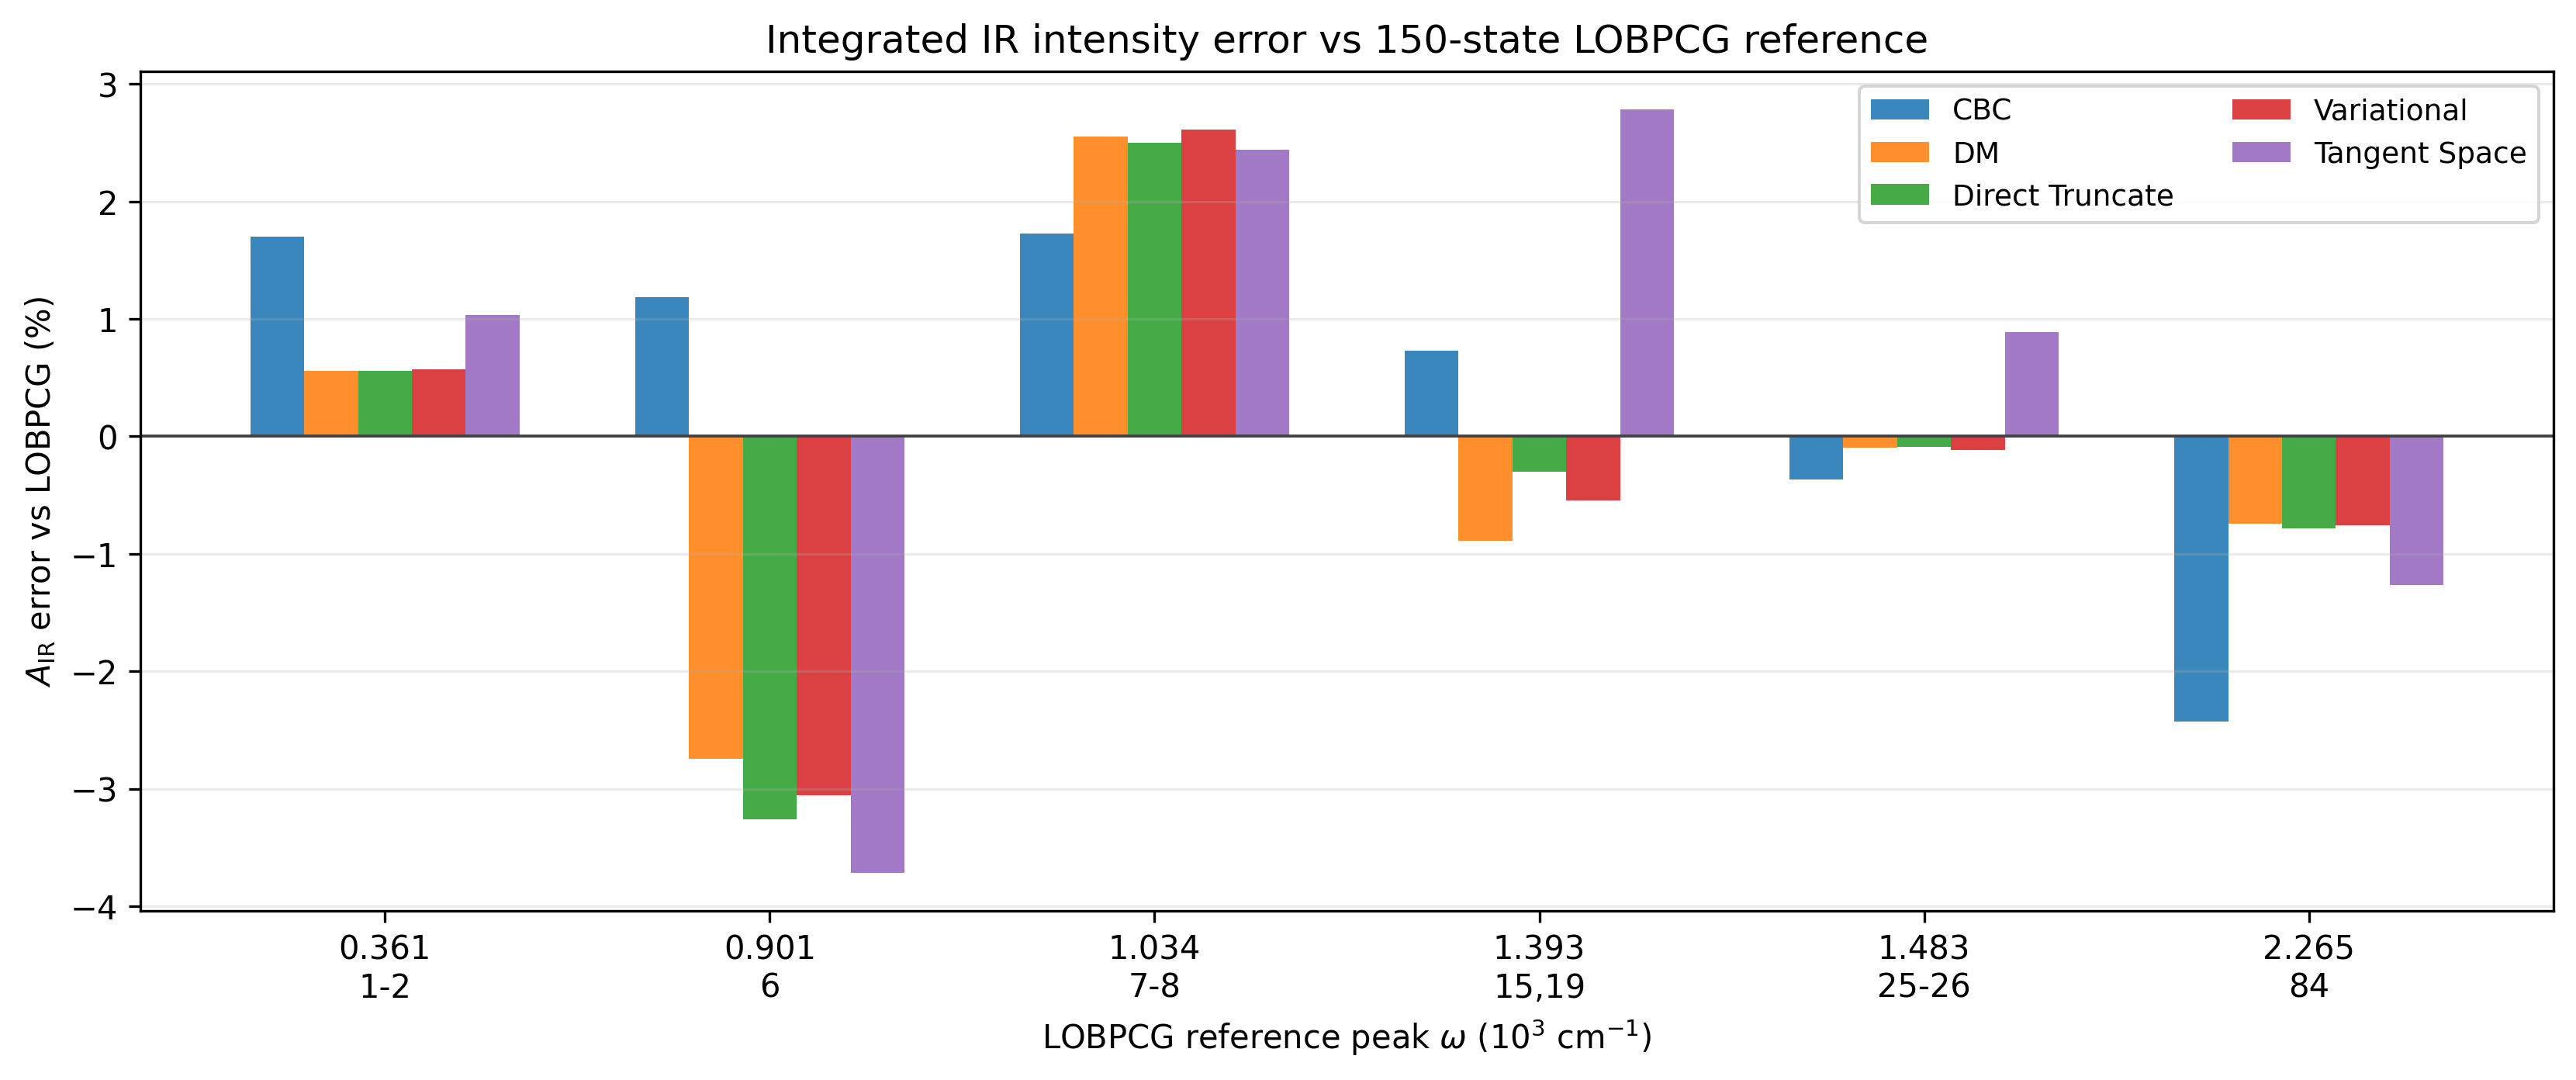

In [ ]:
# --- IR_INTENSITY_ERROR_VS_LOBPCG150_START ---
# Integrated IR intensity comparison using the 150-state LOBPCG reference CSV.
from pathlib import Path
import csv

import numpy as np
import matplotlib.pyplot as plt

ROOT = Path("/Users/link/Desktop/A_Python_code/Chebyshev_upload/Chebyshev")
REFERENCE_DIR = ROOT / "master_thesis_reference" / "threetree" / "max_bond_dim_12"
CBC_RESULT_DIR = ROOT / "CBC_result"
CBC_AREA_COMPARISON_CSV = CBC_RESULT_DIR / "lobpcg_area_comparison.csv"
TANGENT_RESULT_DIR = ROOT / "ch3cn" / "saved_results" / "CH3CN_d20_results_final_threetree_one_node_tangent_coche_K100_L20000"
TANGENT_AREA_COMPARISON_CSV = TANGENT_RESULT_DIR / "d20_tangent_lobpcg150_area_error_comparison.csv"
LOBPCG150_IR_CSV = REFERENCE_DIR / "lobpcg_150_integrated_ir_intensities.csv"
AREA_COMPARISON_CSV = REFERENCE_DIR / "mu0_real_lobpcg150_area_error_comparison.csv"
IR_COMPARISON_CSV = REFERENCE_DIR / "mu0_real_lobpcg150_ir_intensity_error_comparison.csv"
IR_ERROR_PDF = ROOT / "CH3CN_T3NS_12dim_125N_mu0_real_lobpcg150_ir_intensity_errors.pdf"
IR_ERROR_PNG = ROOT / "CH3CN_T3NS_12dim_125N_mu0_real_lobpcg150_ir_intensity_errors.png"

IR_INTENSITY_FACTOR = float(globals().get("IR_INTENSITY_FACTOR", 2.50664))
AU_DIPOLE_TO_DEBYE = float(globals().get("AU_DIPOLE_TO_DEBYE", 2.541746473))
IR_DELTA_SCALE_A = float(globals().get("DELTA_SCALE_A", 1.0))
TANGENT_METHOD = "Tangent Space"

METHODS = ["CBC", "DM", "Direct Truncate", "Variational", TANGENT_METHOD]
METHOD_COLORS = {
    "CBC": "tab:blue",
    "DM": "tab:orange",
    "Direct Truncate": "tab:green",
    "Variational": "tab:red",
    TANGENT_METHOD: "tab:purple",
}


def _as_float(value):
    try:
        return float(value)
    except (TypeError, ValueError):
        return np.nan


def _csv_value(value):
    if isinstance(value, (np.floating, float)) and not np.isfinite(float(value)):
        return ""
    if isinstance(value, (np.integer, int)):
        return int(value)
    if isinstance(value, (np.floating, float)):
        return float(value)
    return value


def _read_csv(path):
    with path.open(newline="") as handle:
        return [dict(row) for row in csv.DictReader(handle)]


def _write_csv(path, rows, fieldnames):
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("w", newline="") as handle:
        writer = csv.DictWriter(handle, fieldnames=fieldnames)
        writer.writeheader()
        for row in rows:
            writer.writerow({key: _csv_value(row.get(key, "")) for key in fieldnames})


def _format_table(rows, columns, max_rows=None):
    shown = rows if max_rows is None else rows[:max_rows]
    rendered = []
    for row in shown:
        rendered_row = []
        for column in columns:
            value = row.get(column, "")
            if isinstance(value, (np.floating, float)):
                if np.isfinite(float(value)):
                    rendered_row.append(f"{float(value):.6g}")
                else:
                    rendered_row.append("nan")
            else:
                rendered_row.append(str(value))
        rendered.append(rendered_row)
    widths = [len(column) for column in columns]
    for rendered_row in rendered:
        widths = [max(width, len(cell)) for width, cell in zip(widths, rendered_row)]
    header = "  ".join(column.ljust(width) for column, width in zip(columns, widths))
    rule = "  ".join("-" * width for width in widths)
    body = ["  ".join(cell.ljust(width) for cell, width in zip(row, widths)) for row in rendered]
    suffix = []
    if max_rows is not None and len(rows) > max_rows:
        suffix = [f"... ({len(rows) - max_rows} more rows)"]
    return "\n".join([header, rule, *body, *suffix])


def _area_to_ir_intensity(peak_E_1000_cm, two_area_au):
    peak_E_1000_cm = _as_float(peak_E_1000_cm)
    two_area_au = _as_float(two_area_au)
    if not np.isfinite(peak_E_1000_cm) or not np.isfinite(two_area_au):
        return np.nan
    peak_cm = 1000.0 * peak_E_1000_cm
    t2_debye2 = two_area_au * IR_DELTA_SCALE_A * AU_DIPOLE_TO_DEBYE**2
    return IR_INTENSITY_FACTOR * peak_cm * t2_debye2


def _load_ir_reference(path):
    rows = []
    with path.open(newline="") as handle:
        for source_row in csv.DictReader(handle):
            peak_E = float(source_row["peak_E"])
            rows.append({
                "lobpcg_peak": f"{peak_E:.3f}",
                "lobpcg_members": source_row.get("rank_range") or source_row.get("initial_indices") or f"{peak_E:.3f}",
                "reference_peak_E": peak_E,
                "lobpcg_A_IR_km_mol": float(source_row["A_IR_km_mol"]),
            })
    return rows


def _load_new_cbc_area_rows(path):
    path = Path(path)
    if not path.is_file():
        return []
    rows = _read_csv(path)
    for row in rows:
        row["method"] = "CBC"
        for key in ["reference_peak_E", "cheb_peak_E", "lobpcg_two_area", "cheb_two_area", "delta_two_area", "area_pct_error"]:
            row[key] = _as_float(row.get(key))
    return rows


def _load_tangent_area_rows(path):
    path = Path(path)
    if not path.is_file():
        return []
    rows = []
    for row in _read_csv(path):
        lobpcg_peak = _as_float(row.get("lobpcg_peak"))
        rows.append({
            "method": TANGENT_METHOD,
            "lobpcg_peak": f"{lobpcg_peak:.3f}" if np.isfinite(lobpcg_peak) else row.get("lobpcg_peak", ""),
            "lobpcg_members": row.get("lobpcg_members", ""),
            "reference_peak_E": _as_float(row.get("reference_peak_E")),
            "cheb_peak": row.get("tangent_peak", ""),
            "cheb_peak_E": _as_float(row.get("tangent_peak_E")),
            "lobpcg_two_area": _as_float(row.get("lobpcg_two_area")),
            "cheb_two_area": _as_float(row.get("tangent_two_area")),
            "delta_two_area": _as_float(row.get("delta_two_area")),
            "area_pct_error": _as_float(row.get("area_pct_error")),
        })
    return rows


def _load_area_rows():
    if "lobpcg_area_comparison_rows" in globals() and lobpcg_area_comparison_rows:
        rows = [dict(row) for row in lobpcg_area_comparison_rows]
    else:
        rows = _read_csv(AREA_COMPARISON_CSV)
    for row in rows:
        for key in ["reference_peak_E", "cheb_peak_E", "lobpcg_two_area", "cheb_two_area", "delta_two_area", "area_pct_error"]:
            row[key] = _as_float(row.get(key))

    new_cbc_rows = _load_new_cbc_area_rows(CBC_AREA_COMPARISON_CSV)
    if new_cbc_rows:
        rows = [
            row for row in rows
            if row.get("method") not in ("CBC", "cheb_ttns_CBC", "cbc")
        ] + new_cbc_rows

    tangent_rows = _load_tangent_area_rows(TANGENT_AREA_COMPARISON_CSV)
    if tangent_rows:
        rows = [row for row in rows if row.get("method") != TANGENT_METHOD] + tangent_rows
    return rows


lobpcg150_ir_reference_rows = _load_ir_reference(LOBPCG150_IR_CSV)
_reference_by_peak = {row["lobpcg_peak"]: row for row in lobpcg150_ir_reference_rows}
_area_rows = _load_area_rows()

lobpcg_ir_comparison_rows = []
for area_row in _area_rows:
    reference = _reference_by_peak.get(str(area_row["lobpcg_peak"]))
    if reference is None:
        continue
    cheb_A = _area_to_ir_intensity(area_row.get("cheb_peak_E"), area_row.get("cheb_two_area"))
    lobpcg_A = float(reference["lobpcg_A_IR_km_mol"])
    delta_A = cheb_A - lobpcg_A if np.isfinite(cheb_A) else np.nan
    pct_error = 100.0 * delta_A / lobpcg_A if np.isfinite(delta_A) and lobpcg_A != 0.0 else np.nan
    lobpcg_ir_comparison_rows.append({
        "method": area_row["method"],
        "lobpcg_peak": reference["lobpcg_peak"],
        "lobpcg_members": reference["lobpcg_members"],
        "reference_peak_E": reference["reference_peak_E"],
        "cheb_peak": area_row.get("cheb_peak", ""),
        "cheb_peak_E": area_row.get("cheb_peak_E", np.nan),
        "lobpcg_A_IR_km_mol": lobpcg_A,
        "cheb_A_IR_km_mol": cheb_A,
        "delta_A_IR_km_mol": delta_A,
        "ir_pct_error": pct_error,
    })

_ir_fields = [
    "method",
    "lobpcg_peak",
    "lobpcg_members",
    "reference_peak_E",
    "cheb_peak",
    "cheb_peak_E",
    "lobpcg_A_IR_km_mol",
    "cheb_A_IR_km_mol",
    "delta_A_IR_km_mol",
    "ir_pct_error",
]
_write_csv(IR_COMPARISON_CSV, lobpcg_ir_comparison_rows, _ir_fields)

fig, ax = plt.subplots(figsize=(11.2, 4.8))
x = np.arange(len(lobpcg150_ir_reference_rows))
width = min(0.14, 0.72 / max(len(METHODS), 1))
offset_center = 0.5 * (len(METHODS) - 1)
for offset_index, method_label in enumerate(METHODS):
    method_rows = {row["lobpcg_peak"]: row for row in lobpcg_ir_comparison_rows if row["method"] == method_label}
    values = [
        _as_float(method_rows.get(ref["lobpcg_peak"], {}).get("ir_pct_error"))
        for ref in lobpcg150_ir_reference_rows
    ]
    ax.bar(
        x + (offset_index - offset_center) * width,
        values,
        width=width,
        label=method_label,
        color=METHOD_COLORS[method_label],
        alpha=0.88,
    )
ax.axhline(0.0, color="0.25", linewidth=0.9)
ax.set_xticks(x)
ax.set_xticklabels([f"{ref['reference_peak_E']:.3f}\n{ref['lobpcg_members']}" for ref in lobpcg150_ir_reference_rows])
ax.set_xlabel(r"LOBPCG reference peak $\omega$ ($10^3$ cm$^{-1}$)")
ax.set_ylabel(r"$A_{\mathrm{IR}}$ error vs LOBPCG (%)")
ax.set_title("Integrated IR intensity error vs 150-state LOBPCG reference")
ax.grid(axis="y", alpha=0.25)
ax.legend(frameon=True, fontsize=9, ncol=2)
fig.tight_layout()
fig.savefig(IR_ERROR_PDF, bbox_inches="tight")
fig.savefig(IR_ERROR_PNG, dpi=300, bbox_inches="tight")
plt.show()

print("150-state LOBPCG integrated IR reference peaks:")
print(_format_table(lobpcg150_ir_reference_rows, ["lobpcg_peak", "lobpcg_members", "reference_peak_E", "lobpcg_A_IR_km_mol"]))
print("\nChebyshev integrated IR intensity error vs 150-state LOBPCG:")
print(_format_table(lobpcg_ir_comparison_rows, _ir_fields))
print(f"\nNew CBC area rows loaded from: {CBC_AREA_COMPARISON_CSV}")
print(f"Tangent Space area rows loaded from: {TANGENT_AREA_COMPARISON_CSV}")
print(f"Saved IR comparison CSV: {IR_COMPARISON_CSV}")
print(f"Saved IR error figures: {IR_ERROR_PDF} and {IR_ERROR_PNG}")
# --- IR_INTENSITY_ERROR_VS_LOBPCG150_END ---


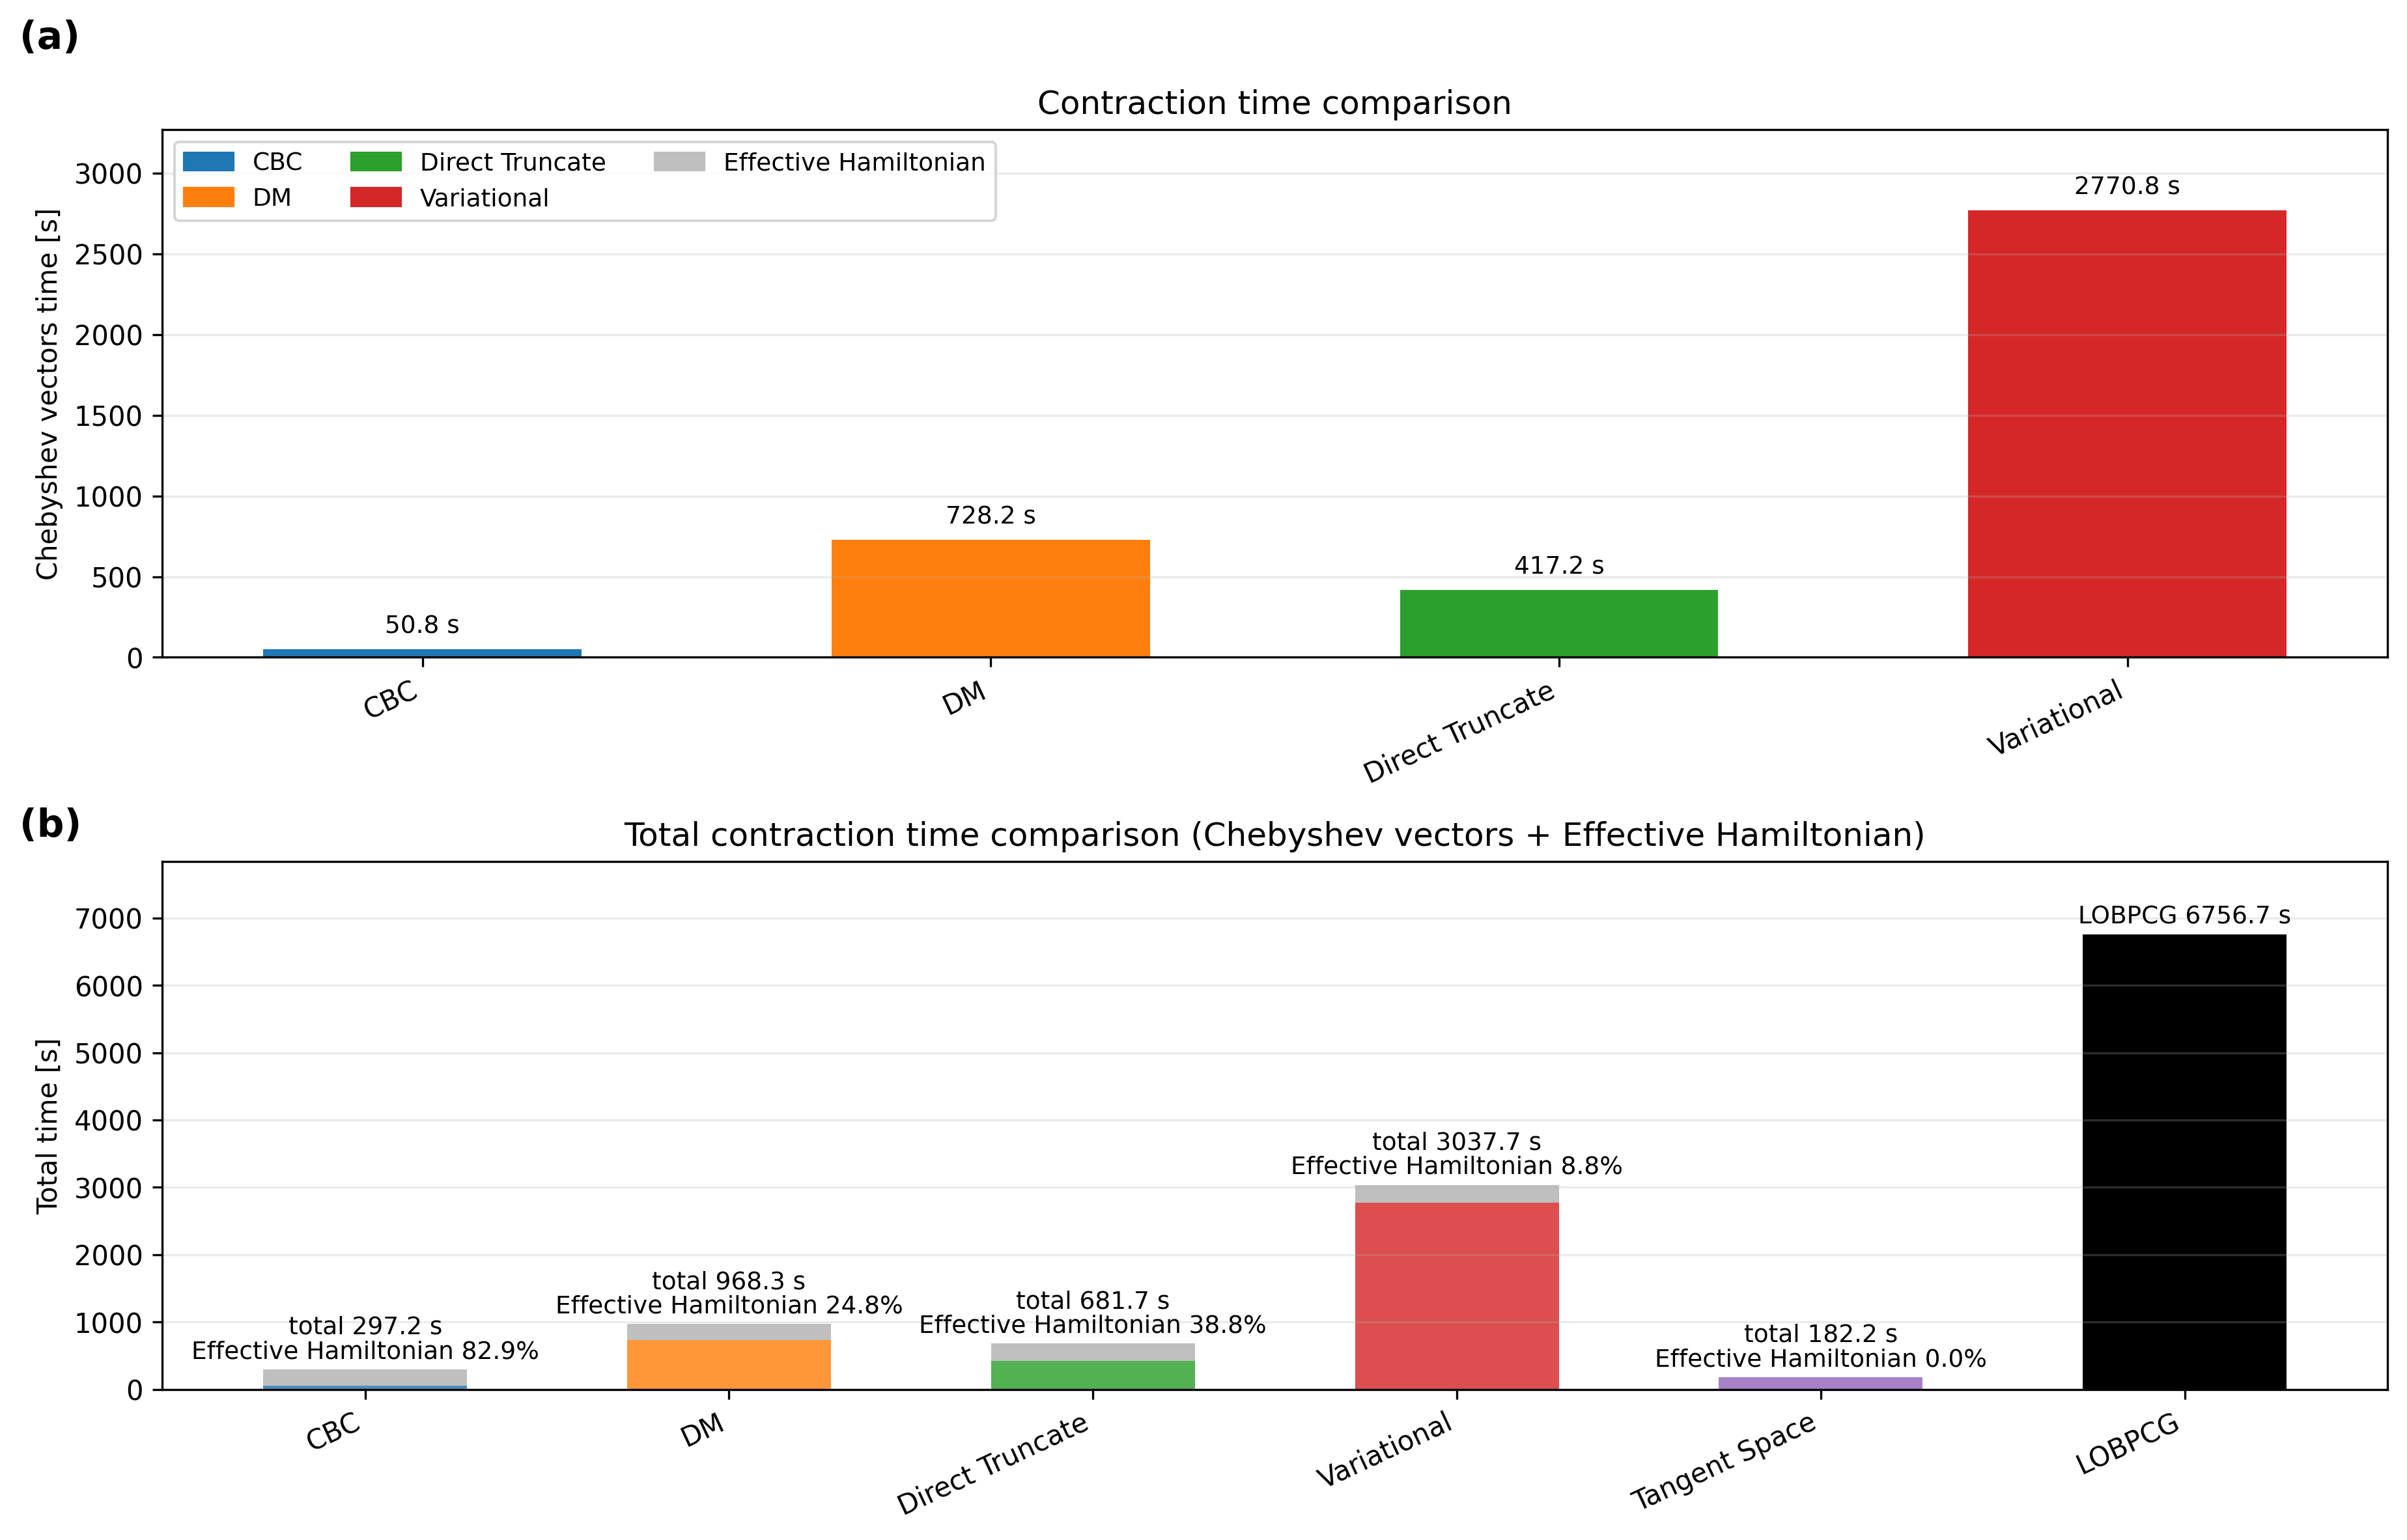

In [ ]:
# --- CHEBYSHEV_RUNTIME_TWO_PANEL_ORIGINAL_STYLE_START ---
# Original-style runtime figure: (a) Chebyshev-vector time, (b) total time.
# This cell only uses saved timing numbers; it does not rerun any contractions.
from pathlib import Path
import csv

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

ROOT = Path("/Users/link/Desktop/A_Python_code/Chebyshev_upload/Chebyshev")
CBC_RESULT_DIR = ROOT / "CBC_result"
CBC_RUNTIME_CSV = CBC_RESULT_DIR / "runtime_summary.csv"
TANGENT_RESULT_DIR = ROOT / "ch3cn" / "saved_results" / "CH3CN_d20_results_final_threetree_one_node_tangent_coche_K100_L20000"
TANGENT_RUNTIME_CSV = TANGENT_RESULT_DIR / "d20_tangent_runtime_summary.csv"
RUNTIME_PDF = ROOT / "CH3CN_T3NS_12dim_125N_mu0_real_runtime_comparison_original_style.pdf"
RUNTIME_PNG = ROOT / "CH3CN_T3NS_12dim_125N_mu0_real_runtime_comparison_original_style.png"

TANGENT_METHOD = "Tangent Space"
PANEL_A_METHODS = ["CBC", "DM", "Direct Truncate", "Variational"]
PANEL_B_METHODS = PANEL_A_METHODS + [TANGENT_METHOD]
METHOD_COLORS = {
    "CBC": "tab:blue",
    "DM": "tab:orange",
    "Direct Truncate": "tab:green",
    "Variational": "tab:red",
    TANGENT_METHOD: "tab:purple",
}
RUNTIME_ROWS = [
    {"method": "CBC", "cheb_vector_s": 50.6, "effective_hamiltonian_s": 234.4, "effective_hamiltonian_recorded": True},
    {"method": "DM", "cheb_vector_s": 728.2, "effective_hamiltonian_s": 240.1, "effective_hamiltonian_recorded": True},
    {"method": "Direct Truncate", "cheb_vector_s": 417.2, "effective_hamiltonian_s": 264.5, "effective_hamiltonian_recorded": True},
    {"method": "Variational", "cheb_vector_s": 2770.8, "effective_hamiltonian_s": 266.9, "effective_hamiltonian_recorded": True},
    {"method": TANGENT_METHOD, "cheb_vector_s": 182.18125483812764, "effective_hamiltonian_s": 0.0, "effective_hamiltonian_recorded": False},
]
LOBPCG_TOTAL_TIME_S = 6756.7


def _as_float(value, default=np.nan):
    try:
        return float(value)
    except (TypeError, ValueError):
        return float(default)


def _as_bool(value, default=False):
    if isinstance(value, bool):
        return value
    if value is None:
        return default
    return str(value).strip().lower() in ("1", "true", "yes", "y")


def _load_new_cbc_runtime(path):
    path = Path(path)
    if not path.is_file():
        return None
    with path.open(newline="") as handle:
        for row in csv.DictReader(handle):
            if row.get("method_key") == "cbc" or row.get("method") == "cheb_ttns_CBC":
                return {
                    "method": "CBC",
                    "cheb_vector_s": _as_float(row.get("cheb_vector_s")),
                    "effective_hamiltonian_s": _as_float(row.get("heff_s")),
                    "effective_hamiltonian_recorded": True,
                }
    return None


def _load_tangent_runtime(path):
    path = Path(path)
    if not path.is_file():
        return None
    with path.open(newline="") as handle:
        rows = [dict(row) for row in csv.DictReader(handle)]
    if not rows:
        return None
    cheb_vector_s = sum(_as_float(row.get("projected_actions_total_s"), 0.0) for row in rows)
    heff_s = sum(_as_float(row.get("effective_hamiltonian_time_s"), 0.0) for row in rows)
    heff_recorded = any(_as_bool(row.get("effective_hamiltonian_recorded"), False) for row in rows)
    return {
        "method": TANGENT_METHOD,
        "cheb_vector_s": cheb_vector_s,
        "effective_hamiltonian_s": heff_s,
        "effective_hamiltonian_recorded": heff_recorded,
    }


new_cbc_runtime = _load_new_cbc_runtime(CBC_RUNTIME_CSV)
if new_cbc_runtime is not None:
    RUNTIME_ROWS = [new_cbc_runtime if row["method"] == "CBC" else row for row in RUNTIME_ROWS]

tangent_runtime = _load_tangent_runtime(TANGENT_RUNTIME_CSV)
if tangent_runtime is not None:
    RUNTIME_ROWS = [tangent_runtime if row["method"] == TANGENT_METHOD else row for row in RUNTIME_ROWS]

runtime_by_method = {row["method"]: row for row in RUNTIME_ROWS}
cheb_times_a = np.array([runtime_by_method[method]["cheb_vector_s"] for method in PANEL_A_METHODS], dtype=np.float64)
colors_a = [METHOD_COLORS[method] for method in PANEL_A_METHODS]
x_a = np.arange(len(PANEL_A_METHODS))

cheb_times_b = np.array([runtime_by_method[method]["cheb_vector_s"] for method in PANEL_B_METHODS], dtype=np.float64)
heff_times_b = np.array([runtime_by_method[method]["effective_hamiltonian_s"] for method in PANEL_B_METHODS], dtype=np.float64)
heff_recorded_b = [bool(runtime_by_method[method].get("effective_hamiltonian_recorded", True)) for method in PANEL_B_METHODS]
total_times_b = cheb_times_b + heff_times_b
x_b = np.arange(len(PANEL_B_METHODS))
x_total = np.arange(len(PANEL_B_METHODS) + 1)
colors_b = [METHOD_COLORS[method] for method in PANEL_B_METHODS]

fig, axes = plt.subplots(2, 1, figsize=(12.8, 8.4))
fig.text(0.008, 0.955, "(a)", fontsize=14, fontweight="bold")
fig.text(0.008, 0.475, "(b)", fontsize=14, fontweight="bold")

legend_handles = [
    Patch(color=METHOD_COLORS["CBC"], label="CBC"),
    Patch(color=METHOD_COLORS["DM"], label="DM"),
    Patch(color=METHOD_COLORS["Direct Truncate"], label="Direct Truncate"),
    Patch(color=METHOD_COLORS["Variational"], label="Variational"),
    Patch(color="0.75", label="Effective Hamiltonian"),
]

ax = axes[0]
bars = ax.bar(x_a, cheb_times_a, width=0.56, color=colors_a)
ax.set_title("Contraction time comparison")
ax.set_ylabel("Chebyshev vectors time [s]")
ax.set_xticks(x_a)
ax.set_xticklabels(PANEL_A_METHODS, rotation=25, ha="right")
ax.grid(axis="y", alpha=0.25)
ax.legend(handles=legend_handles, loc="upper left", ncol=3, frameon=True, fontsize=9)
ax.set_ylim(0.0, max(cheb_times_a) * 1.18)
for bar, value in zip(bars, cheb_times_a):
    ax.text(
        bar.get_x() + bar.get_width() / 2.0,
        value + max(cheb_times_a) * 0.025,
        f"{value:.1f} s",
        ha="center",
        va="bottom",
        fontsize=9,
    )

ax = axes[1]
ax.bar(x_b, cheb_times_b, width=0.56, color=colors_b, alpha=0.82)
ax.bar(x_b, heff_times_b, width=0.56, bottom=cheb_times_b, color="0.75")
ax.bar(x_total[-1], LOBPCG_TOTAL_TIME_S, width=0.56, color="black")
ax.set_title("Total contraction time comparison (Chebyshev vectors + Effective Hamiltonian)")
ax.set_ylabel("Total time [s]")
ax.set_xticks(x_total)
ax.set_xticklabels(PANEL_B_METHODS + ["LOBPCG"], rotation=25, ha="right")
ax.grid(axis="y", alpha=0.25)
max_total_time = max(float(np.max(total_times_b)), LOBPCG_TOTAL_TIME_S)
ax.set_ylim(0.0, max_total_time * 1.16)
label_offset = max_total_time * 0.013
for xpos, cheb_value, heff_value, total_value, recorded in zip(x_b, cheb_times_b, heff_times_b, total_times_b, heff_recorded_b):
    if recorded:
        heff_pct = 100.0 * heff_value / total_value if total_value else 0.0
        label = f"total {total_value:.1f} s\nEffective Hamiltonian {heff_pct:.1f}%"
    else:
        label = f"total {total_value:.1f} s\nEffective Hamiltonian not recorded"
    ax.text(
        xpos,
        total_value + label_offset,
        label,
        ha="center",
        va="bottom",
        fontsize=9,
        linespacing=1.05,
    )
ax.text(
    x_total[-1],
    LOBPCG_TOTAL_TIME_S + label_offset,
    f"LOBPCG {LOBPCG_TOTAL_TIME_S:.1f} s",
    ha="center",
    va="bottom",
    fontsize=9,
)

fig.tight_layout(rect=[0.015, 0.04, 0.965, 0.95])
fig.subplots_adjust(left=0.065, right=0.955)
fig.savefig(RUNTIME_PDF, bbox_inches="tight")
fig.savefig(RUNTIME_PNG, dpi=300, bbox_inches="tight")
plt.show()

print("New CBC runtime loaded from:", CBC_RUNTIME_CSV)
print("Tangent Space runtime loaded from:", TANGENT_RUNTIME_CSV)
print("Saved original-style runtime comparison:", RUNTIME_PDF)
print("Saved original-style runtime comparison:", RUNTIME_PNG)
# --- CHEBYSHEV_RUNTIME_TWO_PANEL_ORIGINAL_STYLE_END ---


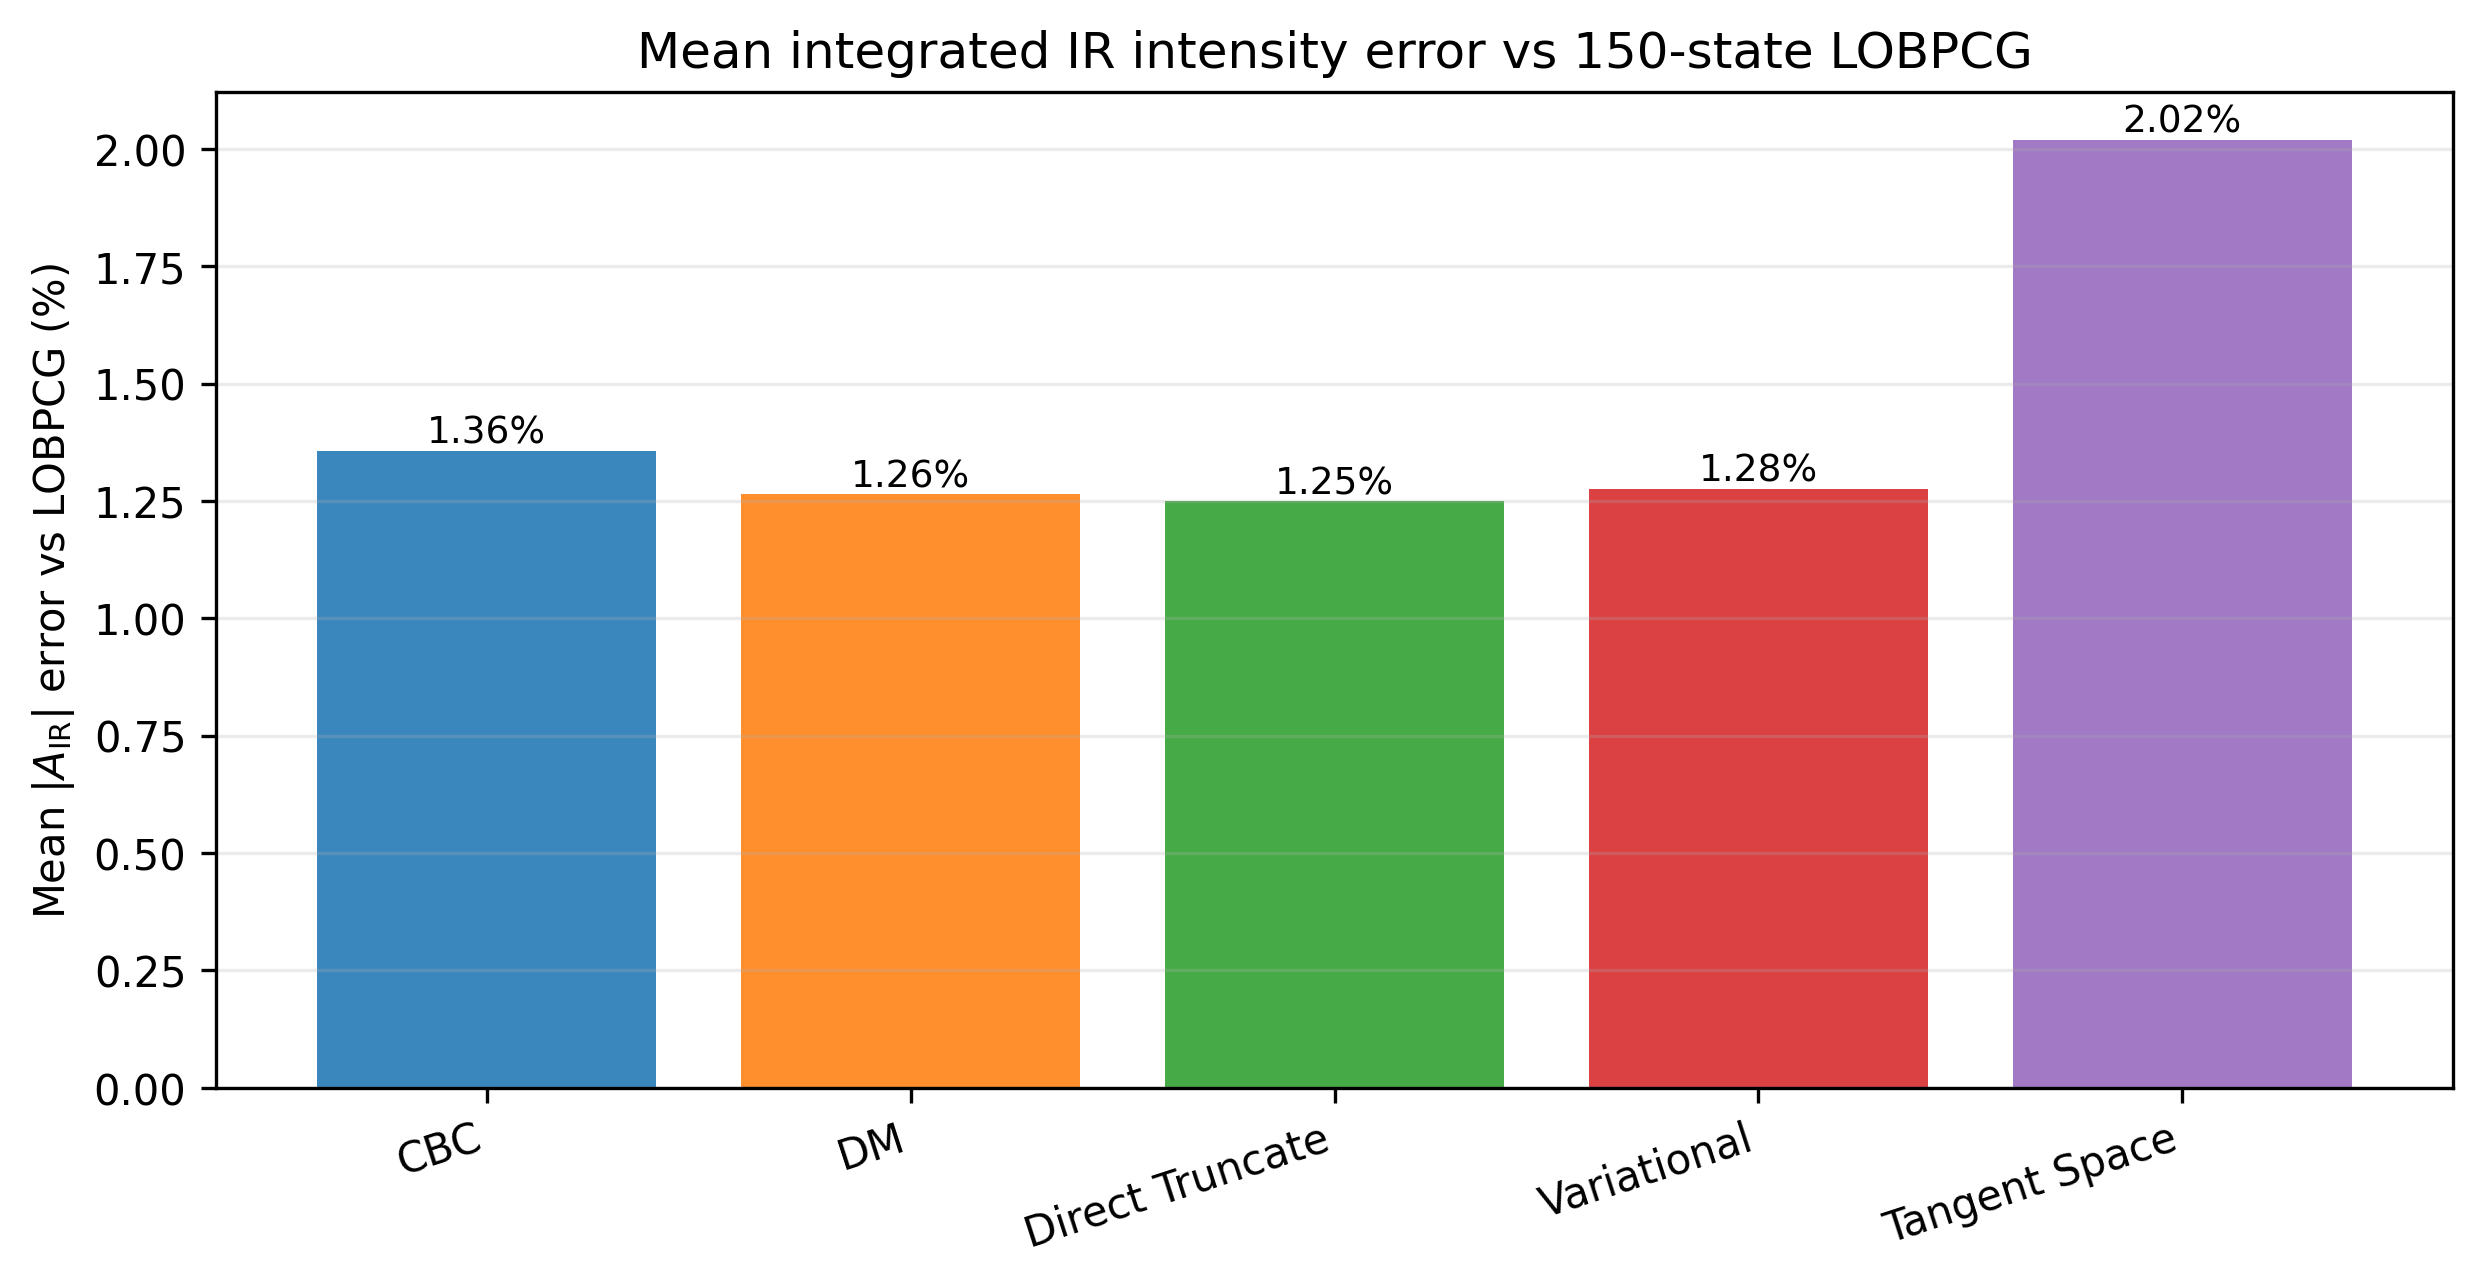

In [ ]:
# --- MEAN_IR_INTENSITY_ERROR_PLOT_LOBPCG150_START ---
# Mean absolute integrated IR intensity error over all 150-state LOBPCG reference peaks.
from pathlib import Path
import csv

import numpy as np
import matplotlib.pyplot as plt

ROOT = Path("/Users/link/Desktop/A_Python_code/Chebyshev_upload/Chebyshev")
REFERENCE_DIR = ROOT / "master_thesis_reference" / "threetree" / "max_bond_dim_12"
CBC_RESULT_DIR = ROOT / "CBC_result"
CBC_IR_COMPARISON_CSV = CBC_RESULT_DIR / "lobpcg_ir_comparison.csv"
TANGENT_RESULT_DIR = ROOT / "ch3cn" / "saved_results" / "CH3CN_d20_results_final_threetree_one_node_tangent_coche_K100_L20000"
TANGENT_AREA_COMPARISON_CSV = TANGENT_RESULT_DIR / "d20_tangent_lobpcg150_area_error_comparison.csv"
LOBPCG150_IR_CSV = REFERENCE_DIR / "lobpcg_150_integrated_ir_intensities.csv"
IR_COMPARISON_CSV = REFERENCE_DIR / "mu0_real_lobpcg150_ir_intensity_error_comparison.csv"
MEAN_IR_ERROR_PDF = ROOT / "CH3CN_T3NS_12dim_125N_mu0_real_lobpcg150_mean_ir_errors.pdf"
MEAN_IR_ERROR_PNG = ROOT / "CH3CN_T3NS_12dim_125N_mu0_real_lobpcg150_mean_ir_errors.png"

IR_INTENSITY_FACTOR = float(globals().get("IR_INTENSITY_FACTOR", 2.50664))
AU_DIPOLE_TO_DEBYE = float(globals().get("AU_DIPOLE_TO_DEBYE", 2.541746473))
IR_DELTA_SCALE_A = float(globals().get("DELTA_SCALE_A", 1.0))
TANGENT_METHOD = "Tangent Space"

METHODS = ["CBC", "DM", "Direct Truncate", "Variational", TANGENT_METHOD]
METHOD_COLORS = {
    "CBC": "tab:blue",
    "DM": "tab:orange",
    "Direct Truncate": "tab:green",
    "Variational": "tab:red",
    TANGENT_METHOD: "tab:purple",
}


def _as_float(value):
    try:
        return float(value)
    except (TypeError, ValueError):
        return np.nan


def _read_csv(path):
    with path.open(newline="") as handle:
        return [dict(row) for row in csv.DictReader(handle)]


def _area_to_ir_intensity(peak_E_1000_cm, two_area_au):
    peak_E_1000_cm = _as_float(peak_E_1000_cm)
    two_area_au = _as_float(two_area_au)
    if not np.isfinite(peak_E_1000_cm) or not np.isfinite(two_area_au):
        return np.nan
    peak_cm = 1000.0 * peak_E_1000_cm
    t2_debye2 = two_area_au * IR_DELTA_SCALE_A * AU_DIPOLE_TO_DEBYE**2
    return IR_INTENSITY_FACTOR * peak_cm * t2_debye2


def _load_new_cbc_ir_rows(path):
    path = Path(path)
    if not path.is_file():
        return []
    rows = _read_csv(path)
    for row in rows:
        row["method"] = "CBC"
        row["ir_pct_error"] = _as_float(row.get("ir_pct_error"))
    return rows


def _load_ir_reference(path):
    rows = []
    for row in _read_csv(path):
        peak_E = float(row["peak_E"])
        rows.append({
            "lobpcg_peak": f"{peak_E:.3f}",
            "reference_peak_E": peak_E,
            "lobpcg_A_IR_km_mol": float(row["A_IR_km_mol"]),
        })
    return rows


def _load_tangent_ir_rows(area_path, reference_rows):
    area_path = Path(area_path)
    if not area_path.is_file():
        return []
    reference_by_peak = {row["lobpcg_peak"]: row for row in reference_rows}
    rows = []
    for area_row in _read_csv(area_path):
        lobpcg_peak_value = _as_float(area_row.get("lobpcg_peak"))
        lobpcg_peak = f"{lobpcg_peak_value:.3f}" if np.isfinite(lobpcg_peak_value) else area_row.get("lobpcg_peak", "")
        reference = reference_by_peak.get(lobpcg_peak)
        if reference is None:
            continue
        cheb_A = _area_to_ir_intensity(area_row.get("tangent_peak_E"), area_row.get("tangent_two_area"))
        lobpcg_A = float(reference["lobpcg_A_IR_km_mol"])
        delta_A = cheb_A - lobpcg_A if np.isfinite(cheb_A) else np.nan
        pct_error = 100.0 * delta_A / lobpcg_A if np.isfinite(delta_A) and lobpcg_A != 0.0 else np.nan
        rows.append({
            "method": TANGENT_METHOD,
            "lobpcg_peak": lobpcg_peak,
            "ir_pct_error": pct_error,
        })
    return rows


def _read_ir_rows():
    if "lobpcg_ir_comparison_rows" in globals() and lobpcg_ir_comparison_rows:
        rows = [dict(row) for row in lobpcg_ir_comparison_rows]
    else:
        rows = _read_csv(IR_COMPARISON_CSV)
    for row in rows:
        row["ir_pct_error"] = _as_float(row.get("ir_pct_error"))

    new_cbc_rows = _load_new_cbc_ir_rows(CBC_IR_COMPARISON_CSV)
    if new_cbc_rows:
        rows = [
            row for row in rows
            if row.get("method") not in ("CBC", "cheb_ttns_CBC", "cbc")
        ] + new_cbc_rows

    tangent_rows = _load_tangent_ir_rows(TANGENT_AREA_COMPARISON_CSV, _load_ir_reference(LOBPCG150_IR_CSV))
    if tangent_rows:
        rows = [row for row in rows if row.get("method") != TANGENT_METHOD] + tangent_rows
    return rows


def _format_table(rows, columns):
    rendered = []
    for row in rows:
        rendered_row = []
        for column in columns:
            value = row.get(column, "")
            if isinstance(value, (np.floating, float)):
                rendered_row.append(f"{float(value):.6g}" if np.isfinite(float(value)) else "nan")
            else:
                rendered_row.append(str(value))
        rendered.append(rendered_row)
    widths = [len(column) for column in columns]
    for rendered_row in rendered:
        widths = [max(width, len(cell)) for width, cell in zip(widths, rendered_row)]
    header = "  ".join(column.ljust(width) for column, width in zip(columns, widths))
    rule = "  ".join("-" * width for width in widths)
    body = ["  ".join(cell.ljust(width) for cell, width in zip(row, widths)) for row in rendered]
    return "\n".join([header, rule, *body])


_rows = _read_ir_rows()
lobpcg_ir_mean_error_rows = []
for method in METHODS:
    values = np.array([
        abs(_as_float(row.get("ir_pct_error")))
        for row in _rows
        if row.get("method") == method and np.isfinite(_as_float(row.get("ir_pct_error")))
    ], dtype=np.float64)
    lobpcg_ir_mean_error_rows.append({
        "method": method,
        "mean_abs_ir_pct_error": float(np.mean(values)) if values.size else np.nan,
        "max_abs_ir_pct_error": float(np.max(values)) if values.size else np.nan,
        "n_peaks": int(values.size),
    })

fig, ax = plt.subplots(figsize=(8.4, 4.4))
x = np.arange(len(METHODS))
values = [row["mean_abs_ir_pct_error"] for row in lobpcg_ir_mean_error_rows]
bars = ax.bar(x, values, color=[METHOD_COLORS[method] for method in METHODS], alpha=0.88)
ax.set_xticks(x)
ax.set_xticklabels(METHODS, rotation=18, ha="right")
ax.set_ylabel(r"Mean $|A_{\mathrm{IR}}|$ error vs LOBPCG (%)")
ax.set_title("Mean integrated IR intensity error vs 150-state LOBPCG")
ax.grid(axis="y", alpha=0.25)
for bar, value in zip(bars, values):
    if np.isfinite(value):
        ax.text(bar.get_x() + bar.get_width() / 2.0, value, f"{value:.2f}%", ha="center", va="bottom", fontsize=9)
fig.tight_layout()
fig.savefig(MEAN_IR_ERROR_PDF, bbox_inches="tight")
fig.savefig(MEAN_IR_ERROR_PNG, dpi=300, bbox_inches="tight")
plt.show()

print("New CBC IR rows loaded from:", CBC_IR_COMPARISON_CSV)
print("Tangent Space area rows loaded from:", TANGENT_AREA_COMPARISON_CSV)
print("Mean absolute integrated IR intensity error vs 150-state LOBPCG:")
print(_format_table(lobpcg_ir_mean_error_rows, ["method", "mean_abs_ir_pct_error", "max_abs_ir_pct_error", "n_peaks"]))
print(f"\nSaved mean IR error figures: {MEAN_IR_ERROR_PDF} and {MEAN_IR_ERROR_PNG}")
# --- MEAN_IR_INTENSITY_ERROR_PLOT_LOBPCG150_END ---


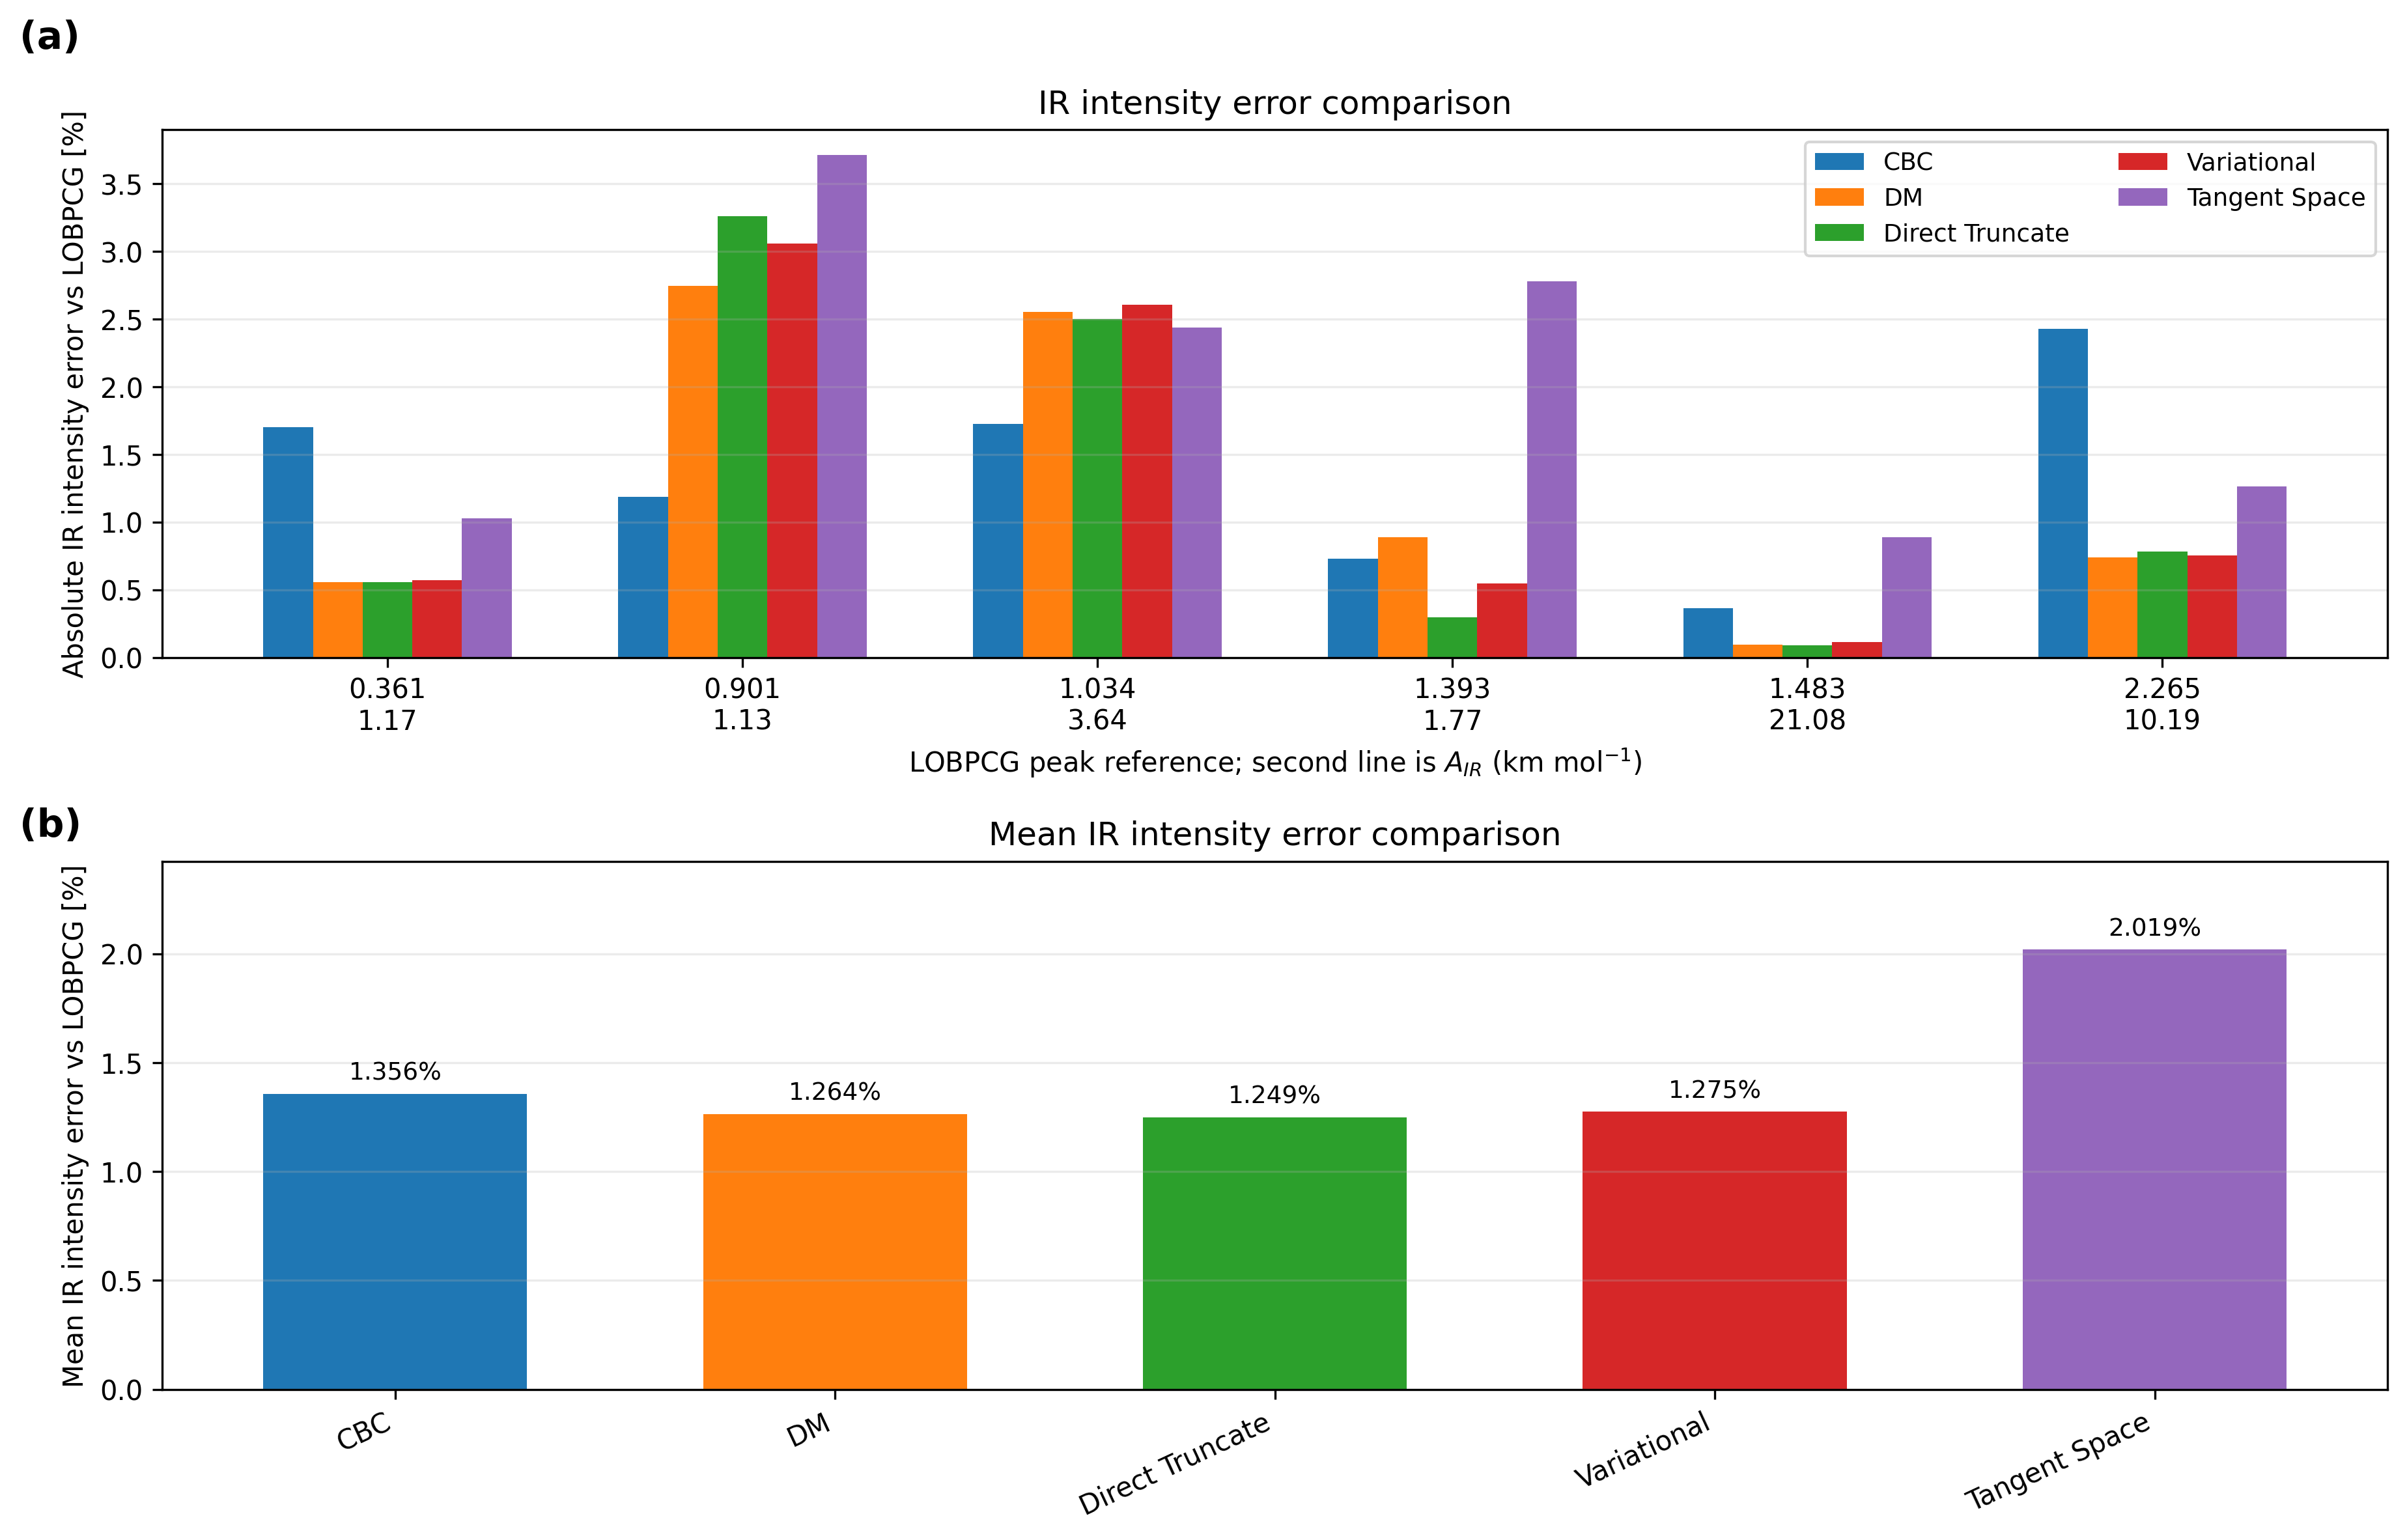

In [ ]:
# --- IR_ERROR_MEAN_TWO_PANEL_ORIGINAL_STYLE_START ---
# Original-style reference figure: (a) absolute peak-wise IR error, (b) mean error.
# This cell reads saved LOBPCG-150 comparison CSV files only.
# CBC rows are replaced by the latest CBC_result rows.
from pathlib import Path
import csv

import numpy as np
import matplotlib.pyplot as plt

ROOT = Path("/Users/link/Desktop/A_Python_code/Chebyshev_upload/Chebyshev")
REFERENCE_DIR = ROOT / "master_thesis_reference" / "threetree" / "max_bond_dim_12"
CBC_RESULT_DIR = ROOT / "CBC_result"
CBC_IR_COMPARISON_CSV = CBC_RESULT_DIR / "lobpcg_ir_comparison.csv"
TANGENT_RESULT_DIR = ROOT / "ch3cn" / "saved_results" / "CH3CN_d20_results_final_threetree_one_node_tangent_coche_K100_L20000"
TANGENT_AREA_COMPARISON_CSV = TANGENT_RESULT_DIR / "d20_tangent_lobpcg150_area_error_comparison.csv"
IR_COMPARISON_CSV = REFERENCE_DIR / "mu0_real_lobpcg150_ir_intensity_error_comparison.csv"
LOBPCG150_IR_CSV = REFERENCE_DIR / "lobpcg_150_integrated_ir_intensities.csv"
IR_MEAN_PDF = ROOT / "CH3CN_T3NS_12dim_125N_mu0_real_lobpcg150_ir_error_mean_original_style.pdf"
IR_MEAN_PNG = ROOT / "CH3CN_T3NS_12dim_125N_mu0_real_lobpcg150_ir_error_mean_original_style.png"

IR_INTENSITY_FACTOR = float(globals().get("IR_INTENSITY_FACTOR", 2.50664))
AU_DIPOLE_TO_DEBYE = float(globals().get("AU_DIPOLE_TO_DEBYE", 2.541746473))
IR_DELTA_SCALE_A = float(globals().get("DELTA_SCALE_A", 1.0))
TANGENT_METHOD = "Tangent Space"

METHODS = ["CBC", "DM", "Direct Truncate", "Variational", TANGENT_METHOD]
METHOD_COLORS = {
    "CBC": "tab:blue",
    "DM": "tab:orange",
    "Direct Truncate": "tab:green",
    "Variational": "tab:red",
    TANGENT_METHOD: "tab:purple",
}


def _as_float(value):
    try:
        return float(value)
    except (TypeError, ValueError):
        return np.nan


def _read_csv(path):
    with path.open(newline="") as handle:
        return [dict(row) for row in csv.DictReader(handle)]


def _area_to_ir_intensity(peak_E_1000_cm, two_area_au):
    peak_E_1000_cm = _as_float(peak_E_1000_cm)
    two_area_au = _as_float(two_area_au)
    if not np.isfinite(peak_E_1000_cm) or not np.isfinite(two_area_au):
        return np.nan
    peak_cm = 1000.0 * peak_E_1000_cm
    t2_debye2 = two_area_au * IR_DELTA_SCALE_A * AU_DIPOLE_TO_DEBYE**2
    return IR_INTENSITY_FACTOR * peak_cm * t2_debye2


def _load_tangent_ir_rows(area_path, reference_rows):
    area_path = Path(area_path)
    if not area_path.is_file():
        return []
    reference_by_peak = {row["lobpcg_peak"]: row for row in reference_rows}
    rows = []
    for area_row in _read_csv(area_path):
        lobpcg_peak_value = _as_float(area_row.get("lobpcg_peak"))
        lobpcg_peak = f"{lobpcg_peak_value:.3f}" if np.isfinite(lobpcg_peak_value) else area_row.get("lobpcg_peak", "")
        reference = reference_by_peak.get(lobpcg_peak)
        if reference is None:
            continue
        cheb_A = _area_to_ir_intensity(area_row.get("tangent_peak_E"), area_row.get("tangent_two_area"))
        lobpcg_A = float(reference["A_IR_km_mol"])
        delta_A = cheb_A - lobpcg_A if np.isfinite(cheb_A) else np.nan
        pct_error = 100.0 * delta_A / lobpcg_A if np.isfinite(delta_A) and lobpcg_A != 0.0 else np.nan
        rows.append({
            "method": TANGENT_METHOD,
            "lobpcg_peak": lobpcg_peak,
            "lobpcg_members": area_row.get("lobpcg_members", ""),
            "reference_peak_E": reference["peak_E"],
            "cheb_peak": area_row.get("tangent_peak", ""),
            "cheb_peak_E": _as_float(area_row.get("tangent_peak_E")),
            "lobpcg_A_IR_km_mol": lobpcg_A,
            "cheb_A_IR_km_mol": cheb_A,
            "delta_A_IR_km_mol": delta_A,
            "ir_pct_error": pct_error,
        })
    return rows


reference_rows = []
for row in _read_csv(LOBPCG150_IR_CSV):
    peak_E = float(row["peak_E"])
    reference_rows.append({
        "lobpcg_peak": f"{peak_E:.3f}",
        "peak_E": peak_E,
        "A_IR_km_mol": float(row["A_IR_km_mol"]),
    })

ir_rows = _read_csv(IR_COMPARISON_CSV)
for row in ir_rows:
    row["ir_pct_error"] = _as_float(row.get("ir_pct_error"))

if CBC_IR_COMPARISON_CSV.is_file():
    new_cbc_rows = _read_csv(CBC_IR_COMPARISON_CSV)
    for row in new_cbc_rows:
        row["method"] = "CBC"
        row["ir_pct_error"] = _as_float(row.get("ir_pct_error"))
    ir_rows = [
        row for row in ir_rows
        if row.get("method") not in ("CBC", "cheb_ttns_CBC", "cbc")
    ] + new_cbc_rows

tangent_ir_rows = _load_tangent_ir_rows(TANGENT_AREA_COMPARISON_CSV, reference_rows)
if tangent_ir_rows:
    ir_rows = [row for row in ir_rows if row.get("method") != TANGENT_METHOD] + tangent_ir_rows

fig, axes = plt.subplots(2, 1, figsize=(12.8, 8.4))
fig.text(0.008, 0.955, "(a)", fontsize=14, fontweight="bold")
fig.text(0.008, 0.475, "(b)", fontsize=14, fontweight="bold")

ax = axes[0]
x = np.arange(len(reference_rows))
width = min(0.14, 0.72 / max(len(METHODS), 1))
offset_center = 0.5 * (len(METHODS) - 1)
for offset_index, method in enumerate(METHODS):
    rows_by_peak = {row["lobpcg_peak"]: row for row in ir_rows if row.get("method") == method}
    values = [
        abs(_as_float(rows_by_peak.get(ref["lobpcg_peak"], {}).get("ir_pct_error")))
        for ref in reference_rows
    ]
    ax.bar(
        x + (offset_index - offset_center) * width,
        values,
        width=width,
        label=method,
        color=METHOD_COLORS[method],
    )
ax.set_title("IR intensity error comparison")
ax.set_ylabel("Absolute IR intensity error vs LOBPCG [%]")
ax.set_xticks(x)
ax.set_xticklabels([
    f"{ref['peak_E']:.3f}\n{ref['A_IR_km_mol']:.2f}"
    for ref in reference_rows
])
ax.set_xlabel(r"LOBPCG peak reference; second line is $A_{IR}$ (km mol$^{-1}$)")
ax.grid(axis="y", alpha=0.25)
ax.legend(loc="upper right", ncol=2, frameon=True, fontsize=9)

ax = axes[1]
mean_rows = []
for method in METHODS:
    values = np.array([
        abs(_as_float(row.get("ir_pct_error")))
        for row in ir_rows
        if row.get("method") == method and np.isfinite(_as_float(row.get("ir_pct_error")))
    ], dtype=np.float64)
    mean_rows.append({
        "method": method,
        "mean_abs_ir_pct_error": float(np.mean(values)) if values.size else np.nan,
    })
mean_values = [row["mean_abs_ir_pct_error"] for row in mean_rows]
bars = ax.bar(
    np.arange(len(METHODS)),
    mean_values,
    width=0.6,
    color=[METHOD_COLORS[method] for method in METHODS],
)
ax.set_title("Mean IR intensity error comparison")
ax.set_ylabel("Mean IR intensity error vs LOBPCG [%]")
ax.set_xticks(np.arange(len(METHODS)))
ax.set_xticklabels(METHODS, rotation=25, ha="right")
ax.grid(axis="y", alpha=0.25)
finite_mean_values = [value for value in mean_values if np.isfinite(value)]
if finite_mean_values:
    ax.set_ylim(0.0, max(finite_mean_values) * 1.20)
    label_step = max(finite_mean_values) * 0.02
else:
    label_step = 0.0
for bar, value in zip(bars, mean_values):
    if np.isfinite(value):
        ax.text(
            bar.get_x() + bar.get_width() / 2.0,
            value + label_step,
            f"{value:.3f}%",
            ha="center",
            va="bottom",
            fontsize=9,
        )

fig.tight_layout(rect=[0.015, 0.04, 0.965, 0.95])
fig.subplots_adjust(left=0.065, right=0.955)
fig.savefig(IR_MEAN_PDF, bbox_inches="tight")
fig.savefig(IR_MEAN_PNG, dpi=300, bbox_inches="tight")
plt.show()

print("New CBC IR rows loaded from:", CBC_IR_COMPARISON_CSV)
print("Tangent Space area rows loaded from:", TANGENT_AREA_COMPARISON_CSV)
print("Reference peaks used:", [f"{row['peak_E']:.3f}" for row in reference_rows])
print("Mean absolute IR errors:")
for row in mean_rows:
    print(f"  {row['method']}: {row['mean_abs_ir_pct_error']:.6g}%")
print("Saved original-style IR error comparison:", IR_MEAN_PDF)
print("Saved original-style IR error comparison:", IR_MEAN_PNG)
# --- IR_ERROR_MEAN_TWO_PANEL_ORIGINAL_STYLE_END ---
